<a href="https://www.kaggle.com/code/lalit7881/wikipedia-country-eda-73-68?scriptVersionId=352174466" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/faravells/wikipedia-country-statistics-2026/country_stats.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/faravells/wikipedia-country-statistics-2026/country_stats.csv")

In [3]:
df.head()

,Country name,Total in km2,Land in km2,Inland water in km2,% water,Population,% of world population,Population density,HDI,Fertility rate,Mortality rate,% of internet users in population,External debt (billions)
0,Russia,17098246.0,16376870.0,721380.0,4.2,1.460283e+08,1.8,8.54,0.832,1.47,13.27,95.6,299.0637
1,Canada,9984670.0,9093507.0,891163.0,8.9,4.141706e+07,0.5,4.15,0.939,1.33,8.17,94.4,"3,468.2119"
2,China,9596960.0,9326410.0,270550.0,2.8,1.404890e+09,17.0,146.39,0.797,1.03,7.82,91.6,"2,412.0799"
3,United States,9525067.0,9147593.0,377424.0,4.0,3.417849e+08,4.1,35.88,0.938,1.63,8.42,94.7,"30,196.961"
4,Brazil,8510346.0,8460415.0,55352.0,0.6,2.142120e+08,2.6,25.17,0.786,1.59,6.90,84.5,692.6895


In [4]:
df.tail()

,Country name,Total in km2,Land in km2,Inland water in km2,% water,Population,% of world population,Population density,HDI,Fertility rate,Mortality rate,% of internet users in population,External debt (billions)
190,San Marino,61.00,61.00,0.0,0.0,34167.0,0.0004,560.11,0.915,1.17,8.83,97.4,0.352
191,Tuvalu,26.00,26.00,0.0,0.0,10643.0,0.0001,409.35,0.689,3.10,7.90,35.2,0.015
192,Nauru,21.00,20.00,0.0,0.0,11680.0,0.0001,556.19,0.703,3.21,6.39,83.0,0.033
193,Monaco,2.00,2.00,0.0,0.0,38857.0,0.0005,19428.50,NaN,2.09,10.92,99.0,16.5
194,Vatican City,0.44,0.44,0.0,0.0,882.0,0.0000,2004.55,NaN,1.00,NaN,89.2,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Country name                       195 non-null    object 
 1   Total in km2                       195 non-null    float64
 2   Land in km2                        194 non-null    float64
 3   Inland water in km2                194 non-null    float64
 4   % water                            194 non-null    float64
 5   Population                         194 non-null    float64
 6   % of world population              194 non-null    float64
 7   Population density                 194 non-null    float64
 8   HDI                                190 non-null    float64
 9   Fertility rate                     191 non-null    float64
 10  Mortality rate                     187 non-null    float64
 11  % of internet users in population  189 non-null    float64

In [6]:
df.isnull().sum()

Country name                         0
Total in km2                         0
Land in km2                          1
Inland water in km2                  1
% water                              1
Population                           1
% of world population                1
Population density                   1
HDI                                  5
Fertility rate                       4
Mortality rate                       8
% of internet users in population    6
External debt (billions)             5
dtype: int64

In [7]:
df.describe()

,Total in km2,Land in km2,Inland water in km2,% water,Population,% of world population,Population density,HDI,Fertility rate,Mortality rate,% of internet users in population
count,1.950000e+02,1.940000e+02,194.000000,194.000000,1.940000e+02,194.000000,194.000000,190.000000,191.000000,187.000000,189.000000
mean,6.850936e+05,6.646920e+05,20595.489691,2.567784,4.139528e+07,0.496013,317.356701,0.739895,2.349110,7.557166,70.697989
std,1.909728e+06,1.840054e+06,91053.493059,4.103184,1.491410e+08,1.805684,1524.825775,0.150655,1.113958,2.877799,26.917858
min,4.400000e-01,4.400000e-01,0.000000,0.000000,8.820000e+02,0.000000,2.300000,0.388000,0.760000,1.420000,0.000000
25%,2.308250e+04,2.290250e+04,11.500000,0.100000,1.846638e+06,0.020000,33.502500,0.623500,1.490000,5.680000,54.600000
50%,1.184840e+05,1.123250e+05,1592.500000,1.400000,9.244136e+06,0.100000,86.570000,0.761500,1.930000,6.990000,82.000000
75%,5.092450e+05,4.924125e+05,9022.500000,3.175000,3.187902e+07,0.400000,202.202500,0.856750,3.085000,9.235000,91.600000
max,1.709825e+07,1.637687e+07,891163.000000,27.800000,1.429404e+09,17.300000,19428.500000,0.972000,5.840000,21.700000,100.000000


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Country name                          object
Total in km2                         float64
Land in km2                          float64
Inland water in km2                  float64
% water                              float64
Population                           float64
% of world population                float64
Population density                   float64
HDI                                  float64
Fertility rate                       float64
Mortality rate                       float64
% of internet users in population    float64
External debt (billions)              object
dtype: object

In [10]:
df.shape

(195, 13)

In [11]:
df.columns

Index(['Country name', 'Total in km2', 'Land in km2', 'Inland water in km2',
       '% water', 'Population', '% of world population', 'Population density',
       'HDI', 'Fertility rate', 'Mortality rate',
       '% of internet users in population', 'External debt (billions)'],
      dtype='object')

In [12]:
df.nunique()

Country name                         195
Total in km2                         195
Land in km2                          194
Inland water in km2                  138
% water                               67
Population                           194
% of world population                 50
Population density                   194
HDI                                  158
Fertility rate                       140
Mortality rate                       170
% of internet users in population    160
External debt (billions)             188
dtype: int64

## EDA

Dataset Shape:
(195, 13)

Dataset Columns:
Index(['Country name', 'Total in km2', 'Land in km2', 'Inland water in km2',
       '% water', 'Population', '% of world population', 'Population density',
       'HDI', 'Fertility rate', 'Mortality rate',
       '% of internet users in population', 'External debt (billions)'],
      dtype='object')

First 5 Rows:


,Country name,Total in km2,Land in km2,Inland water in km2,% water,Population,% of world population,Population density,HDI,Fertility rate,Mortality rate,% of internet users in population,External debt (billions)
0,Russia,17098246.0,16376870.0,721380.0,4.2,1.460283e+08,1.8,8.54,0.832,1.47,13.27,95.6,299.0637
1,Canada,9984670.0,9093507.0,891163.0,8.9,4.141706e+07,0.5,4.15,0.939,1.33,8.17,94.4,"3,468.2119"
2,China,9596960.0,9326410.0,270550.0,2.8,1.404890e+09,17.0,146.39,0.797,1.03,7.82,91.6,"2,412.0799"
3,United States,9525067.0,9147593.0,377424.0,4.0,3.417849e+08,4.1,35.88,0.938,1.63,8.42,94.7,"30,196.961"
4,Brazil,8510346.0,8460415.0,55352.0,0.6,2.142120e+08,2.6,25.17,0.786,1.59,6.90,84.5,692.6895



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Country name                       195 non-null    object 
 1   Total in km2                       195 non-null    float64
 2   Land in km2                        194 non-null    float64
 3   Inland water in km2                194 non-null    float64
 4   % water                            194 non-null    float64
 5   Population                         194 non-null    float64
 6   % of world population              194 non-null    float64
 7   Population density                 194 non-null    float64
 8   HDI                                190 non-null    float64
 9   Fertility rate                     191 non-null    float64
 10  Mortality rate                     187 non-null    float64
 11  % of internet users in population  1

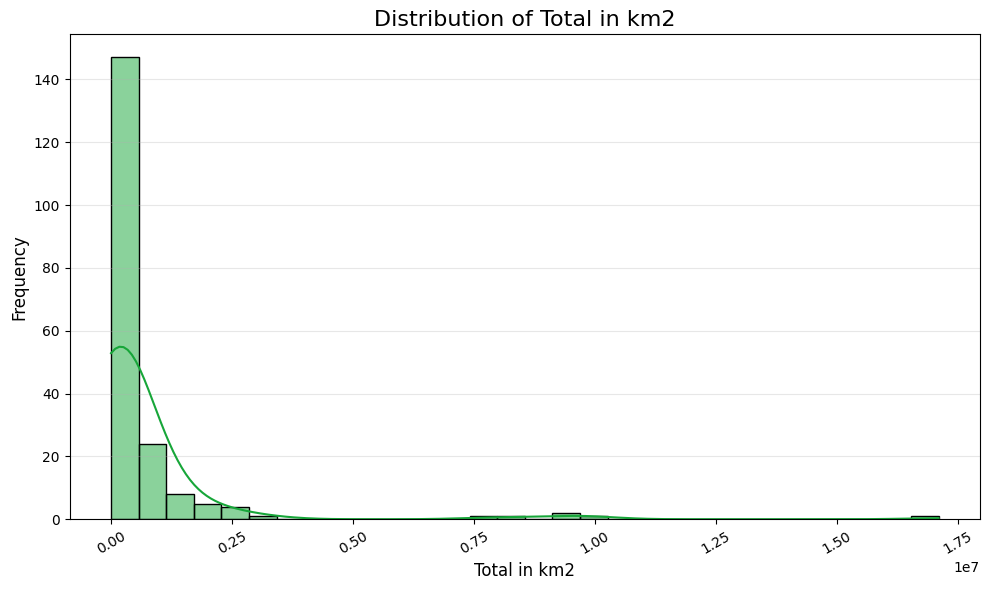

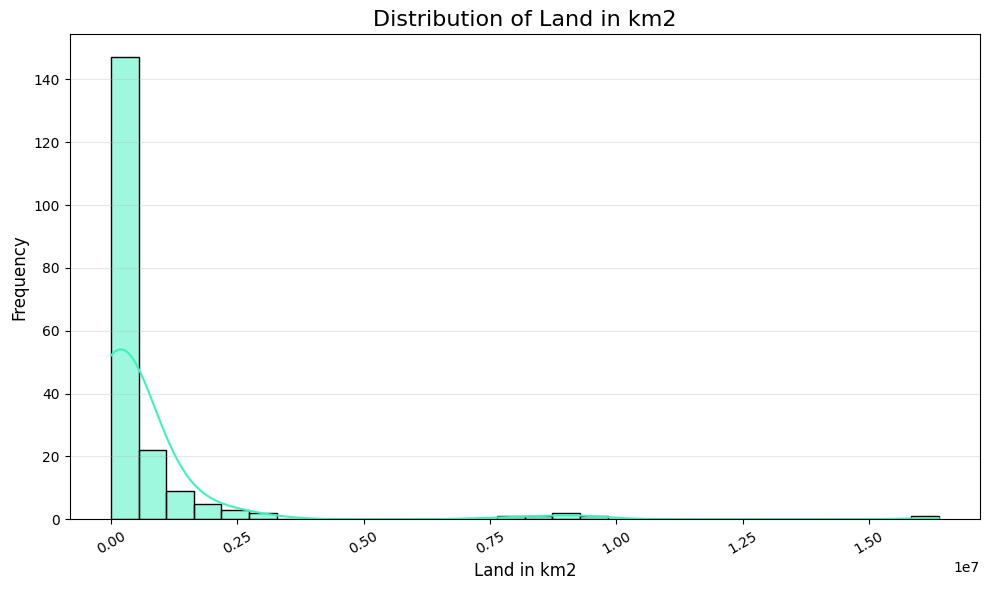

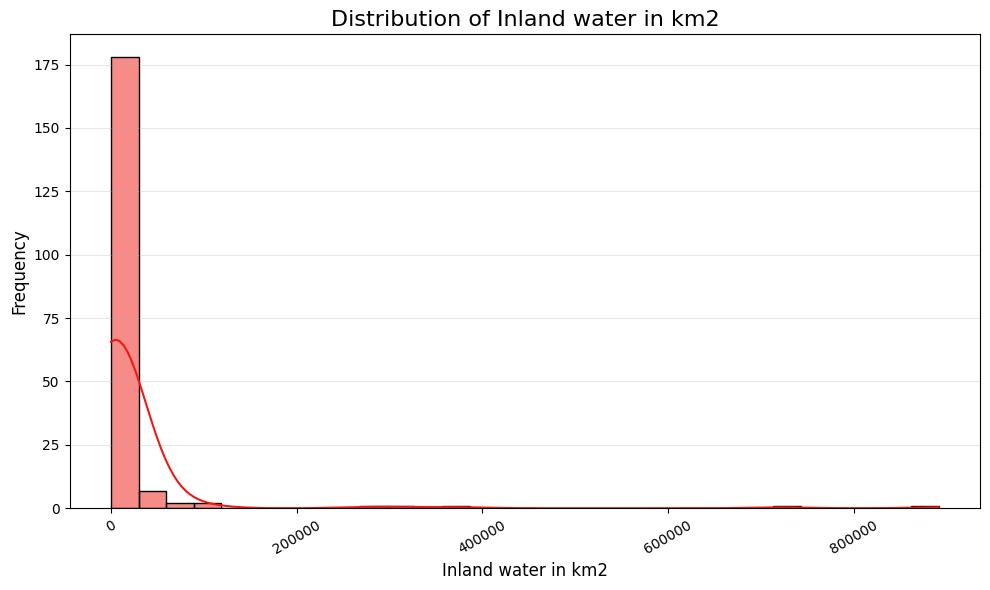

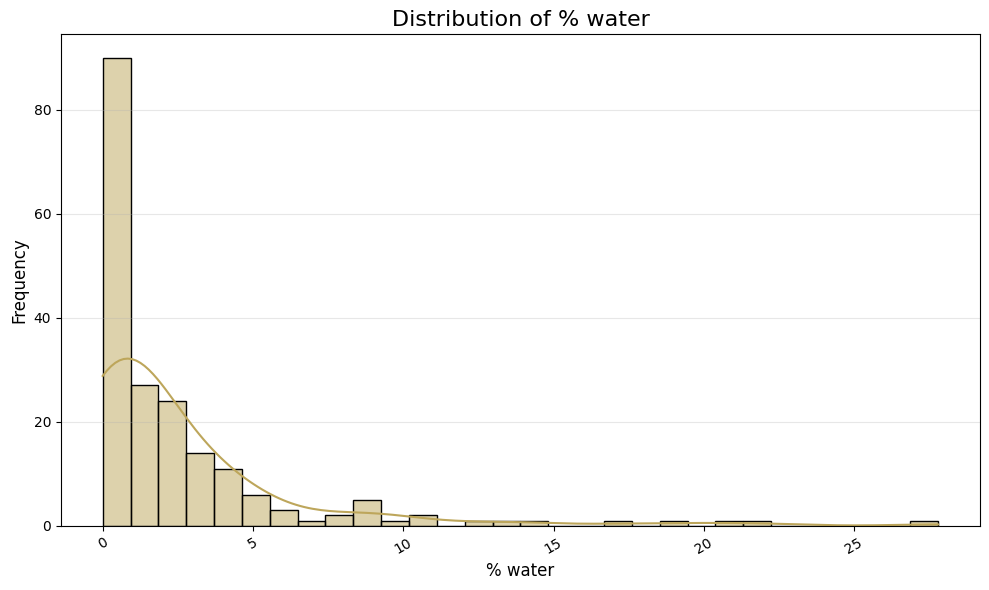

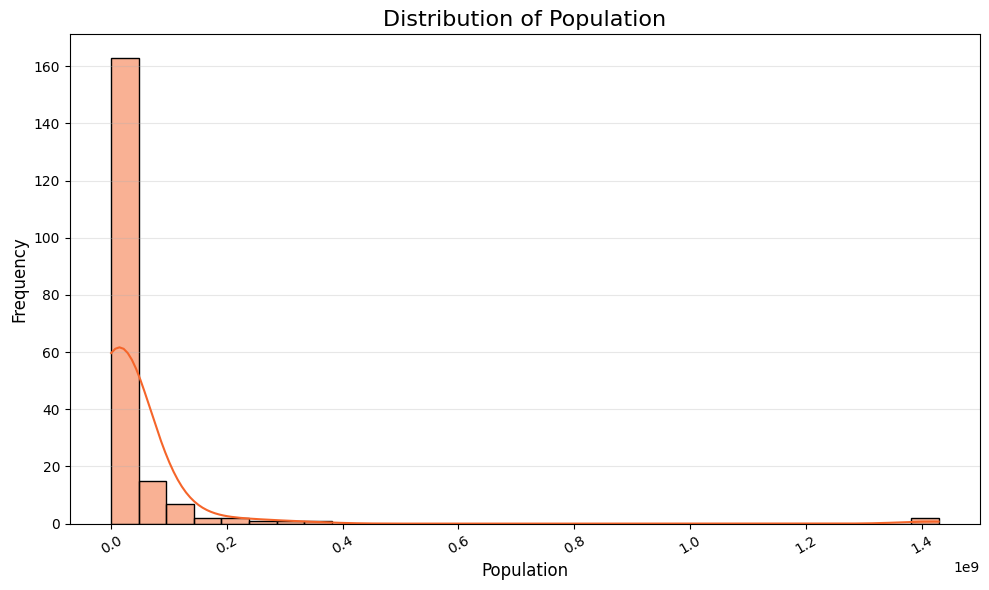

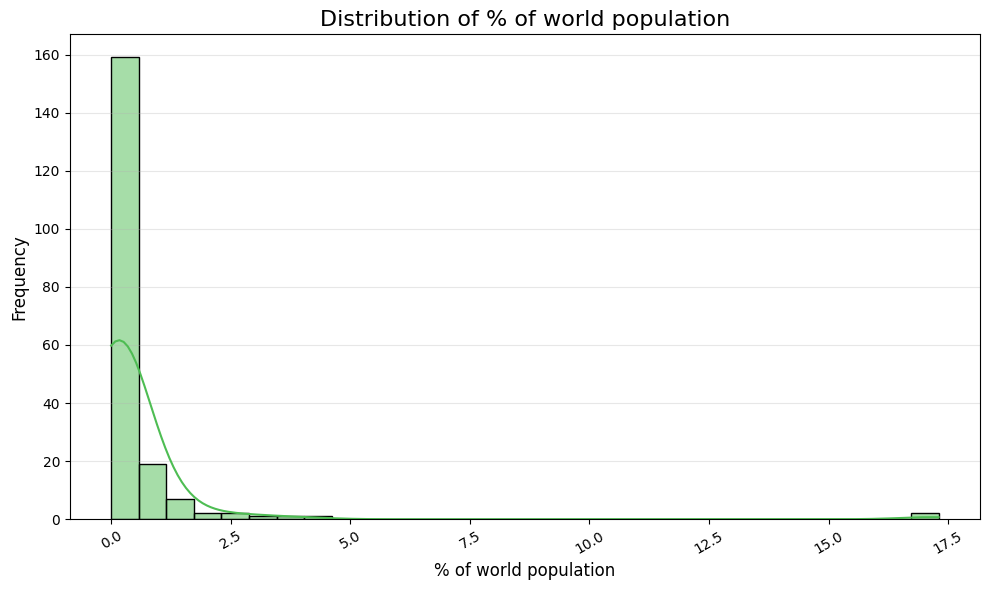

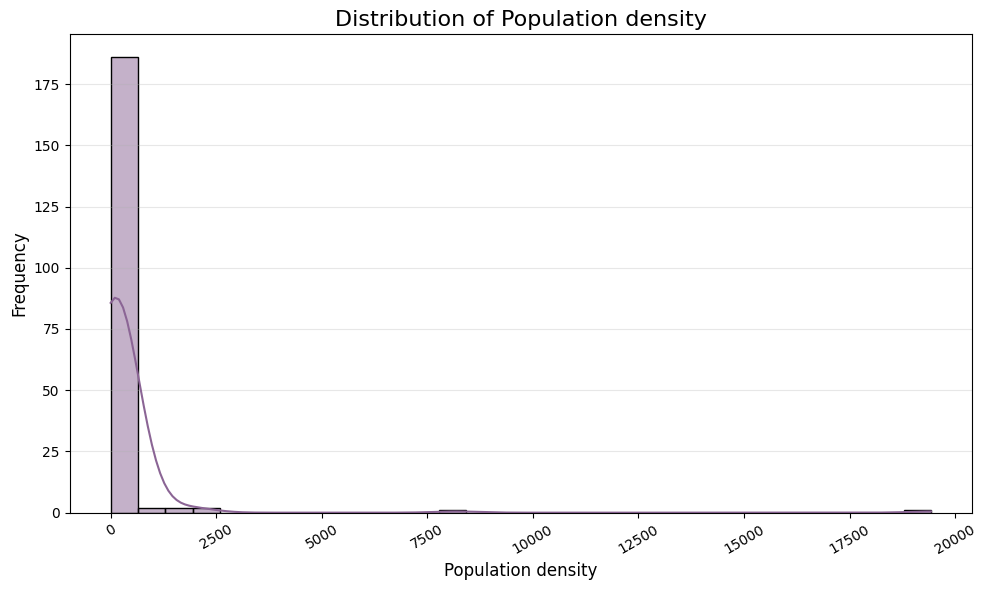

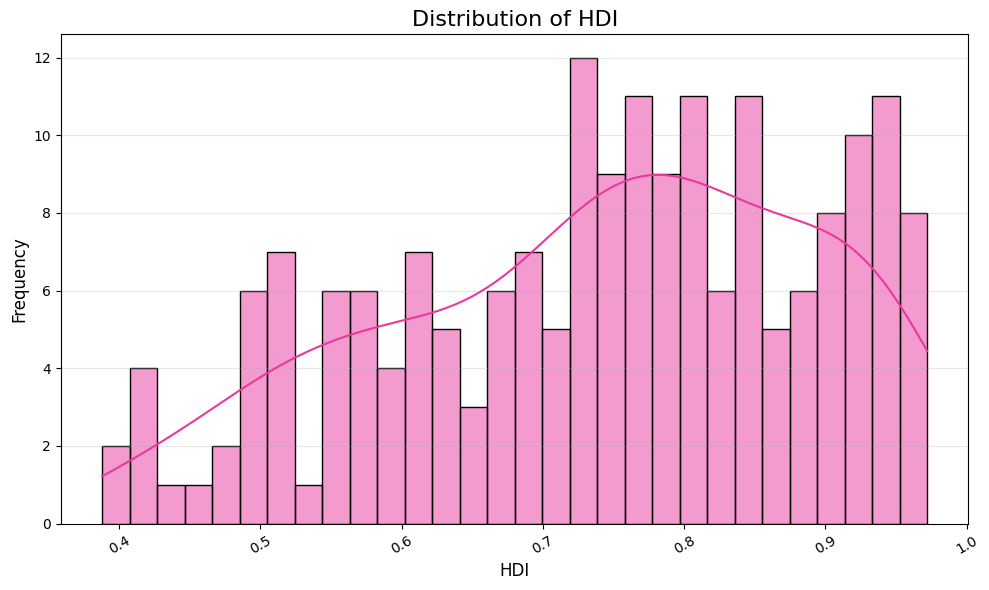

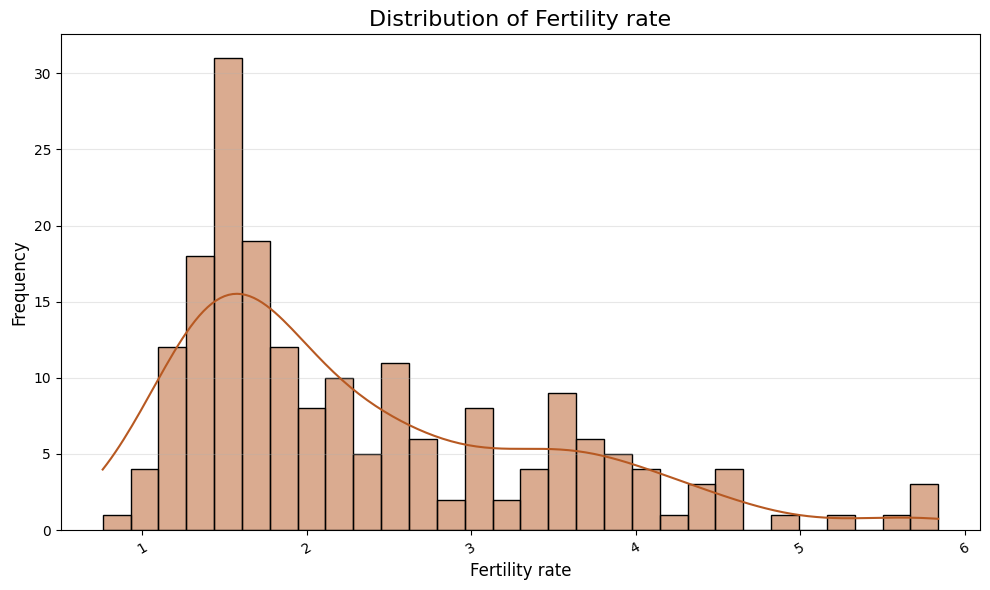

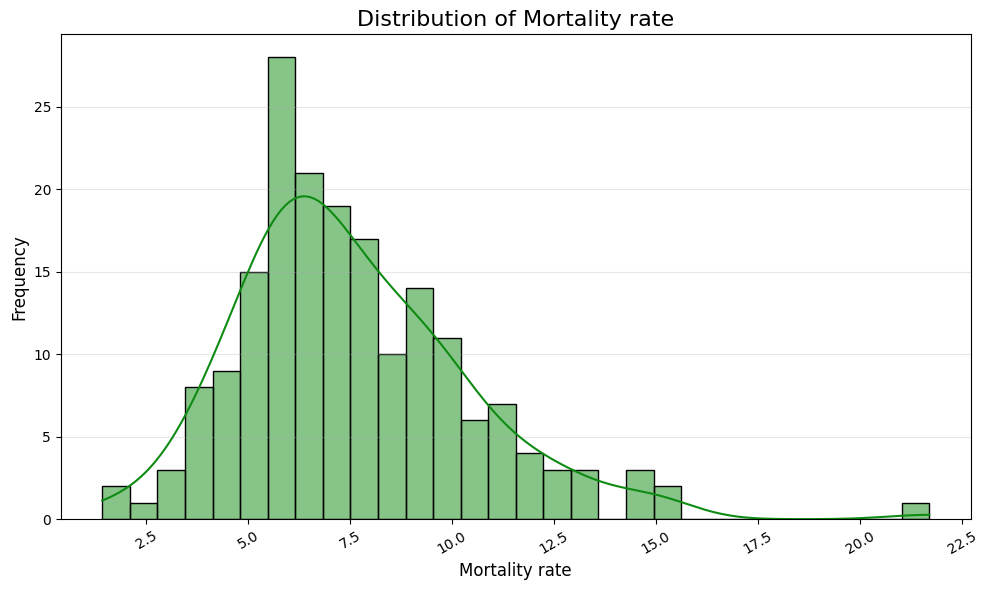

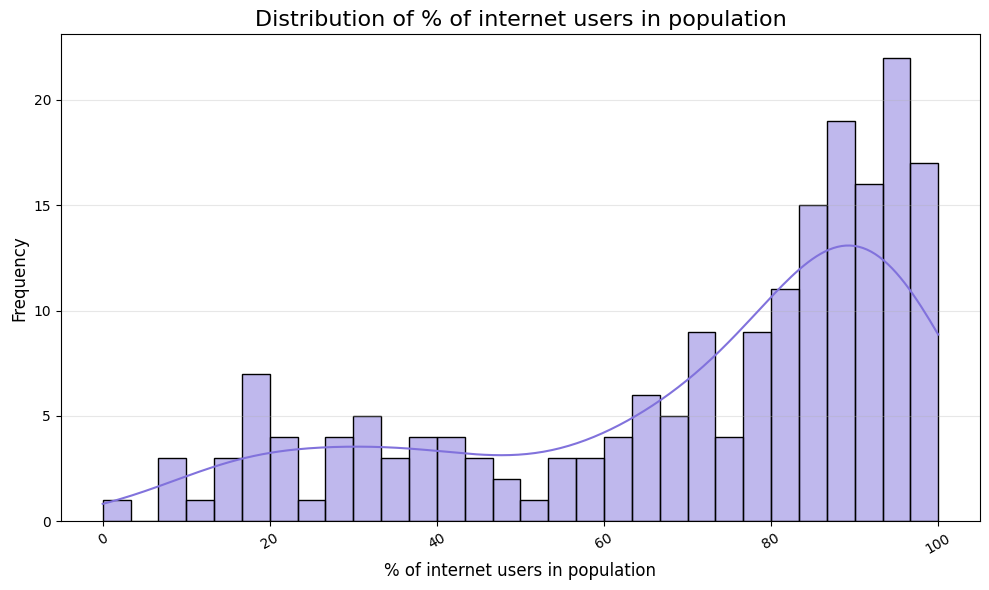

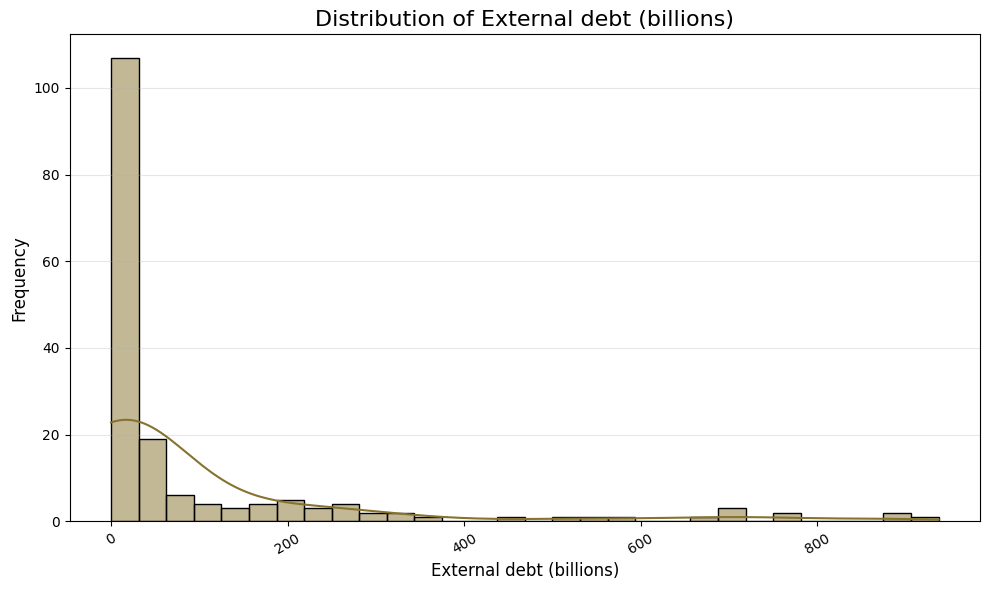

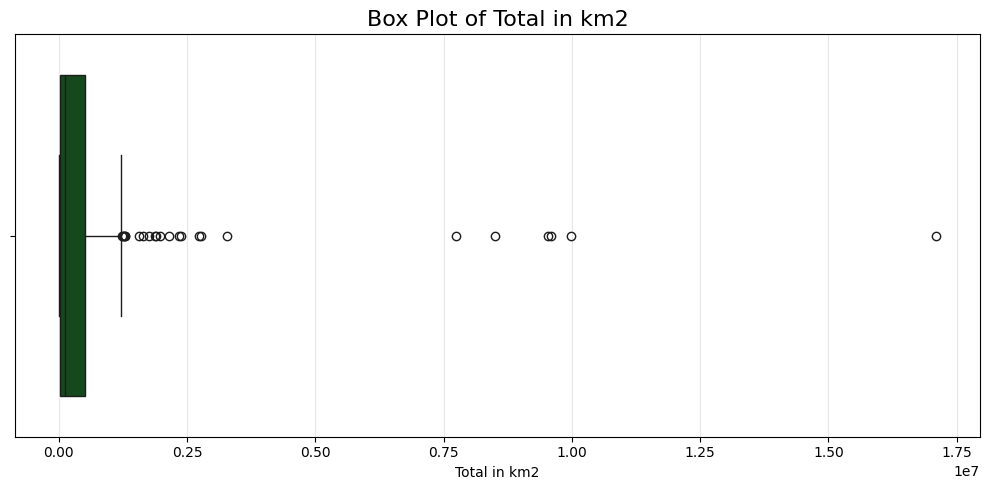

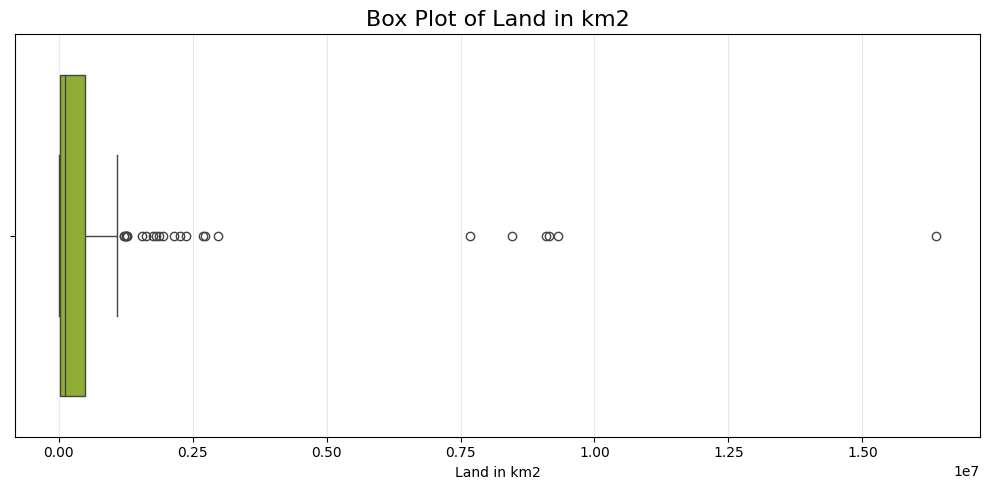

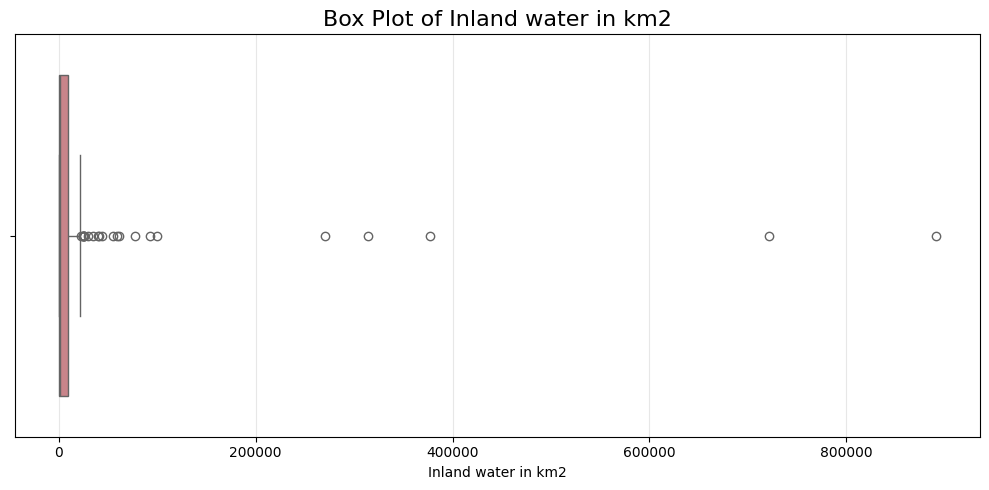

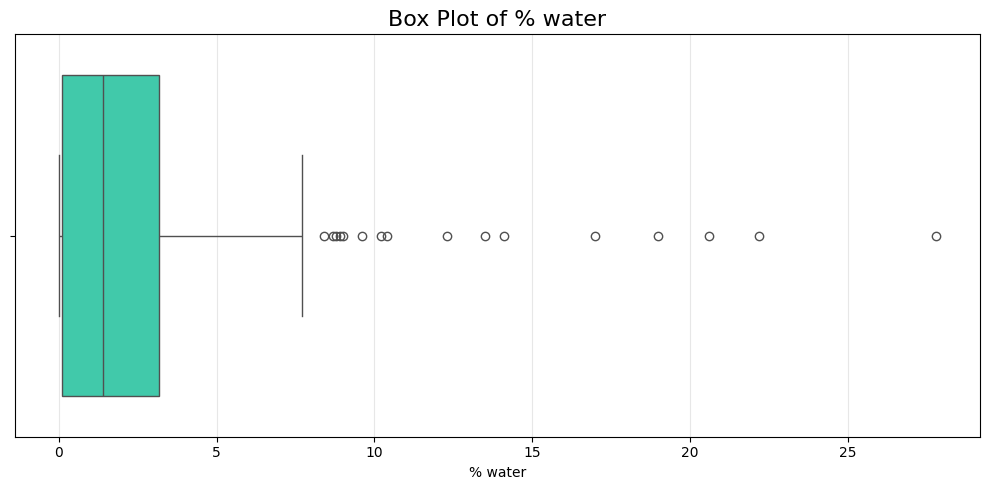

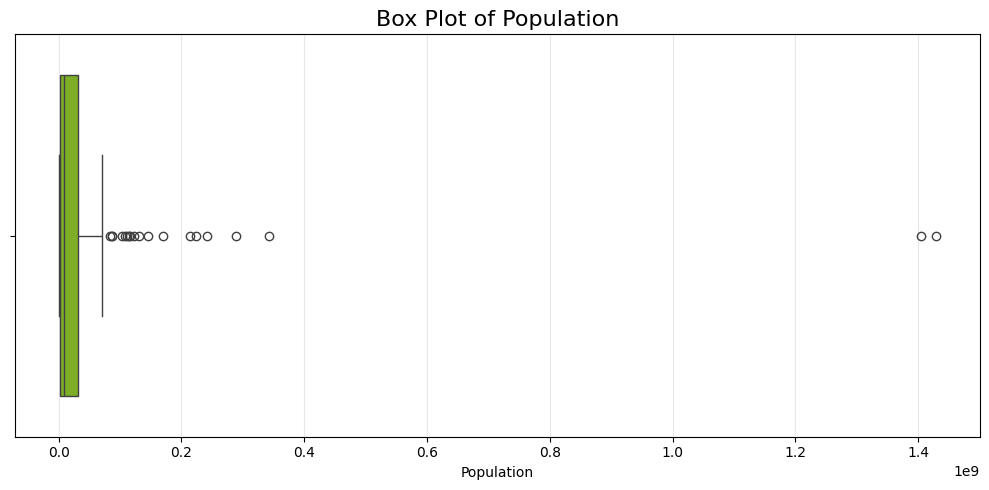

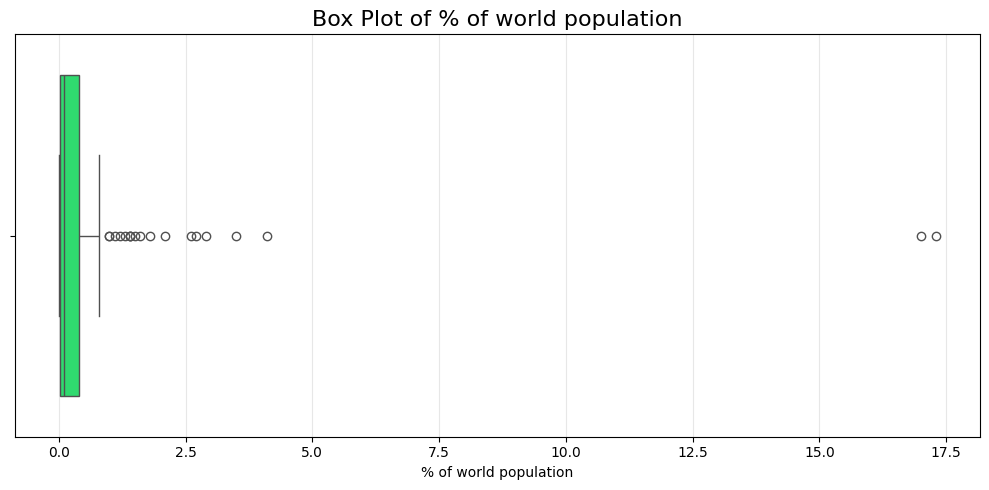

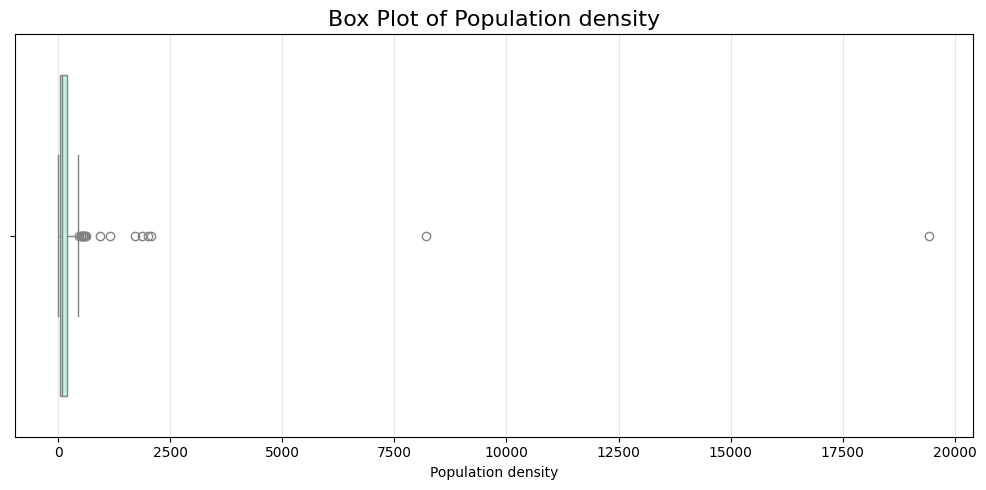

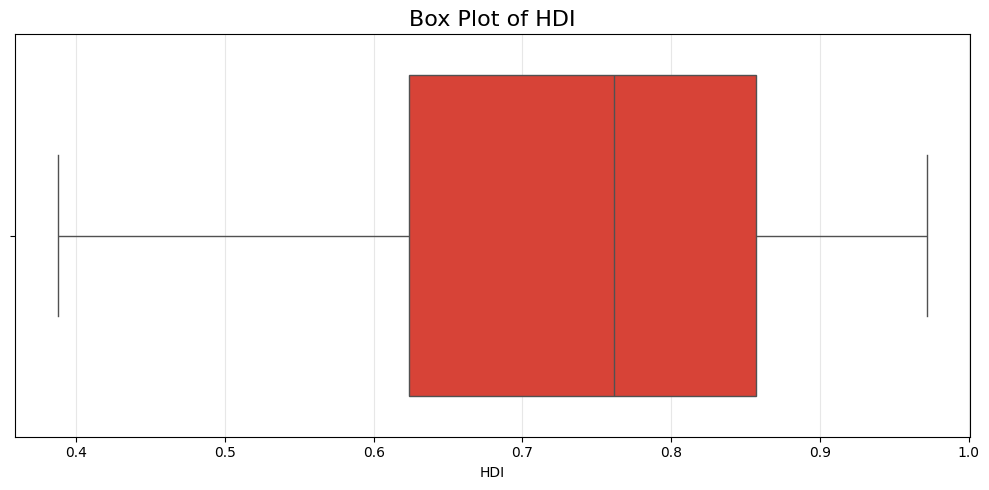

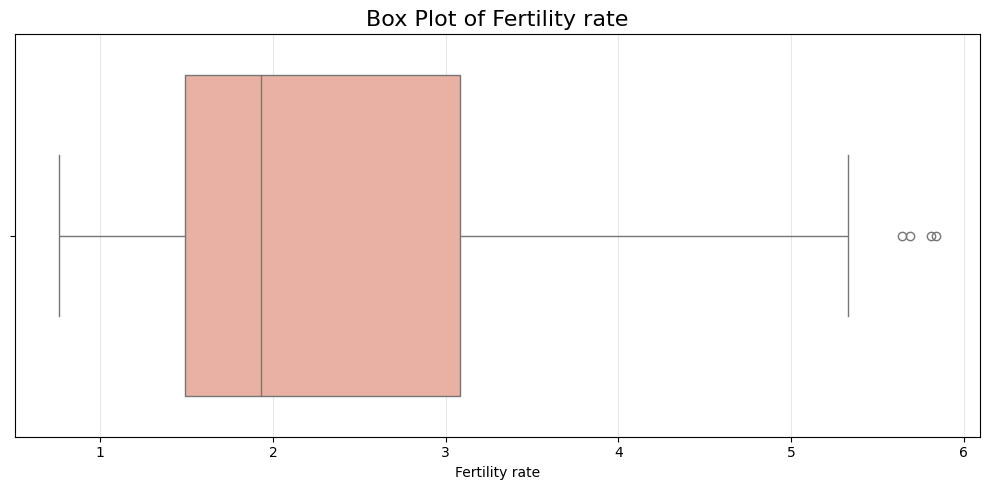

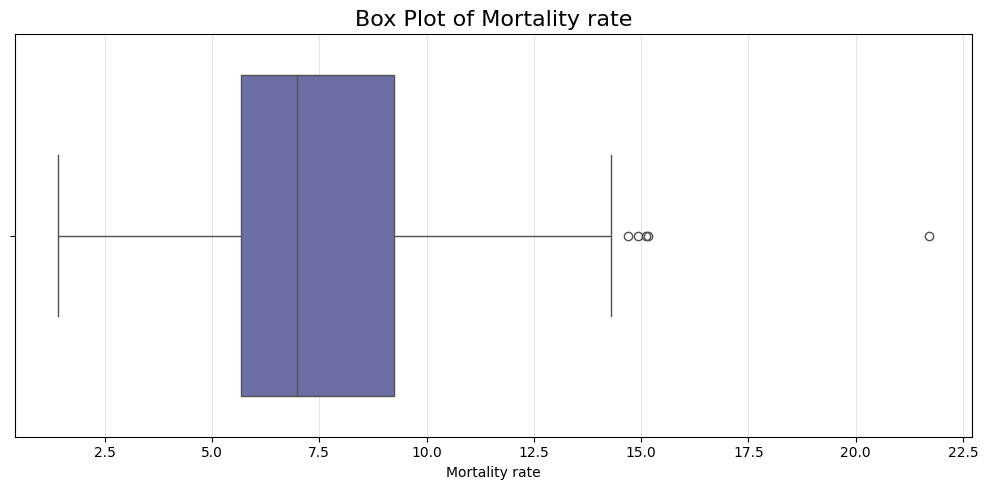

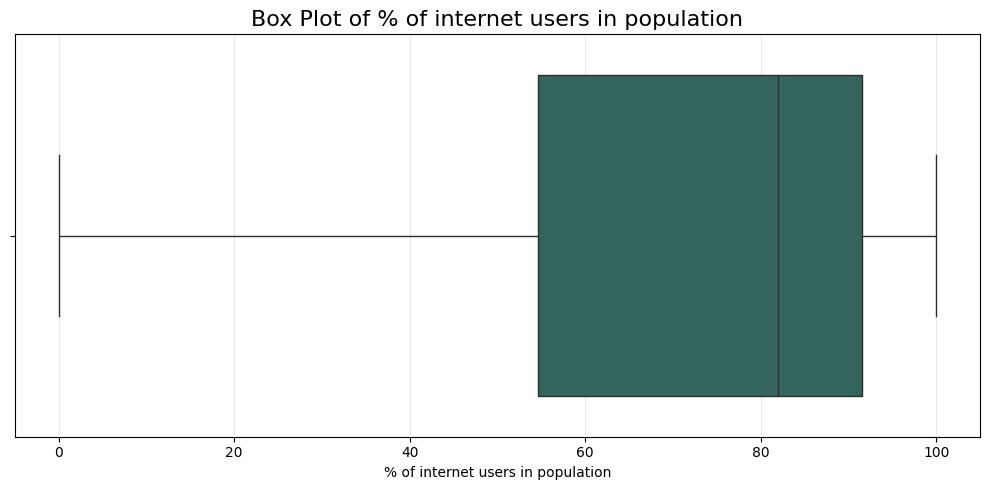

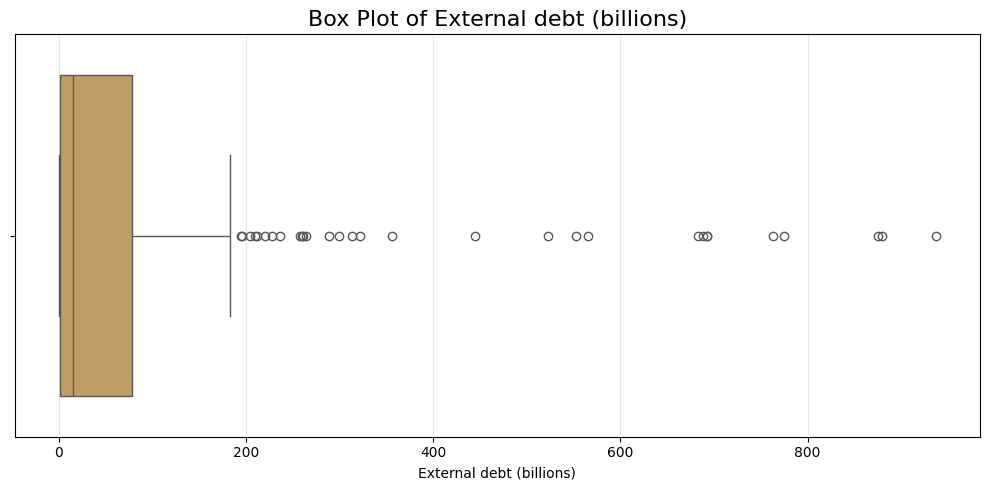

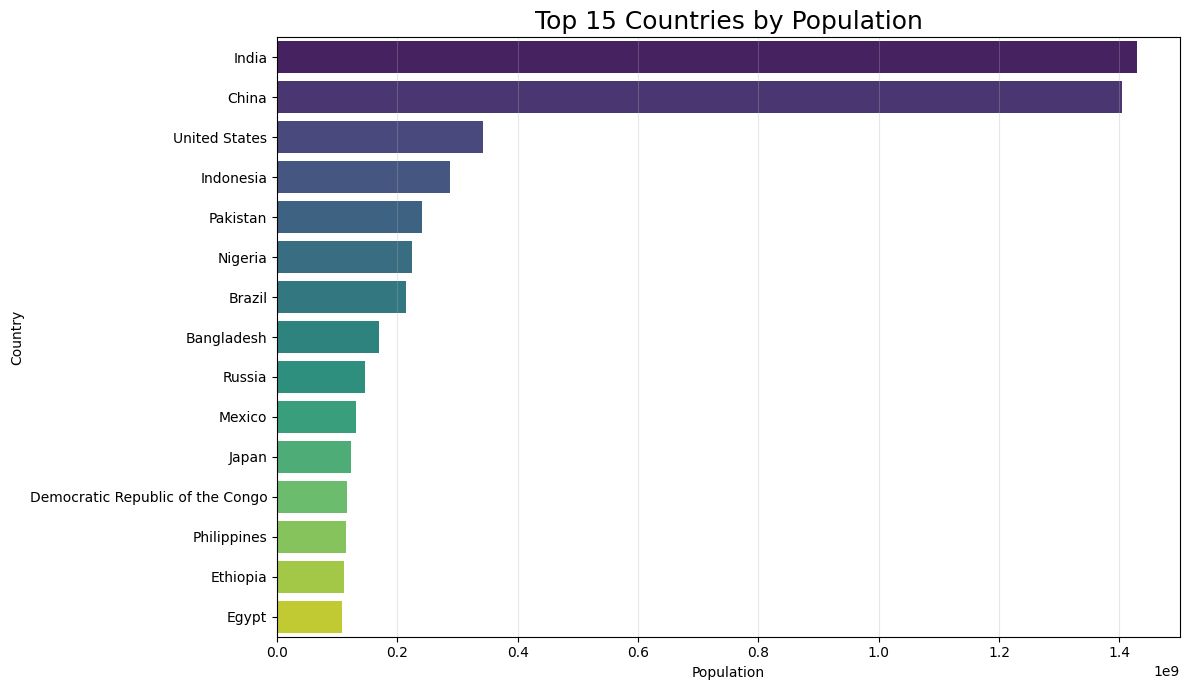

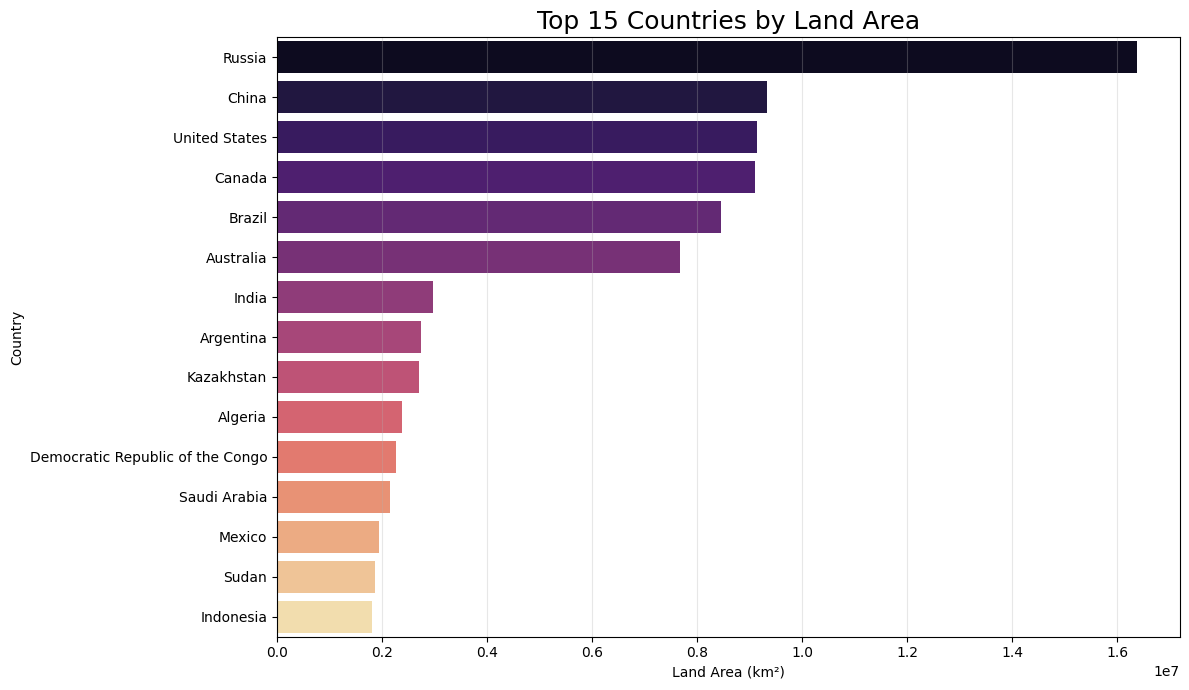

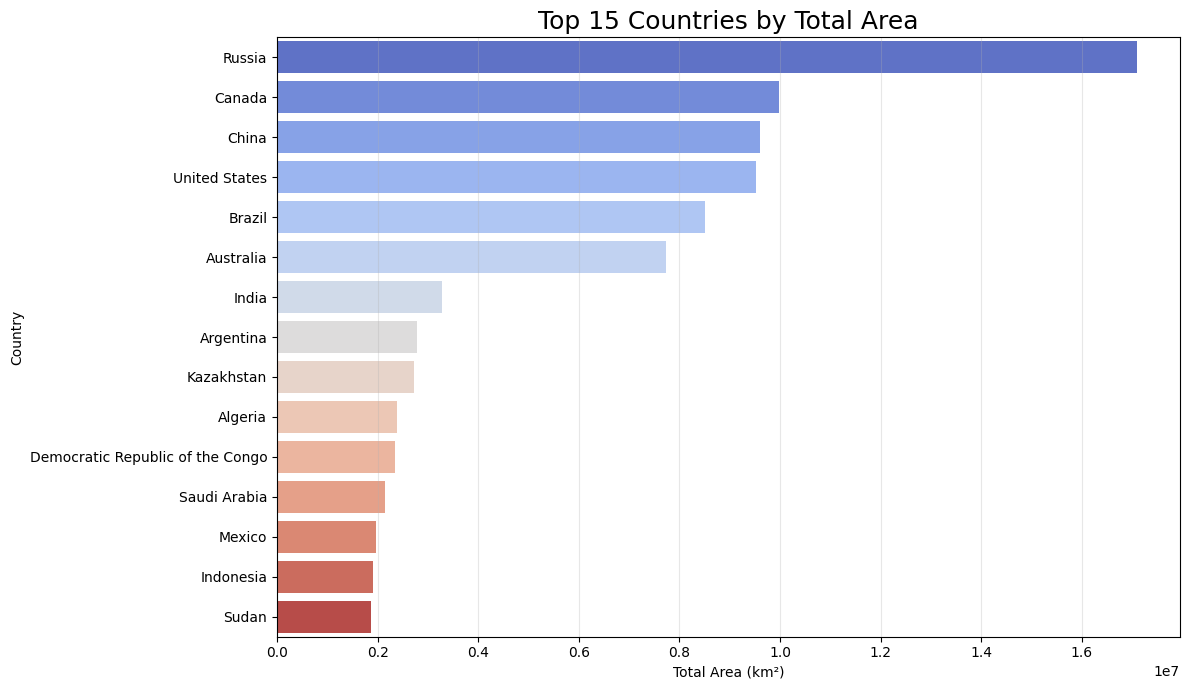

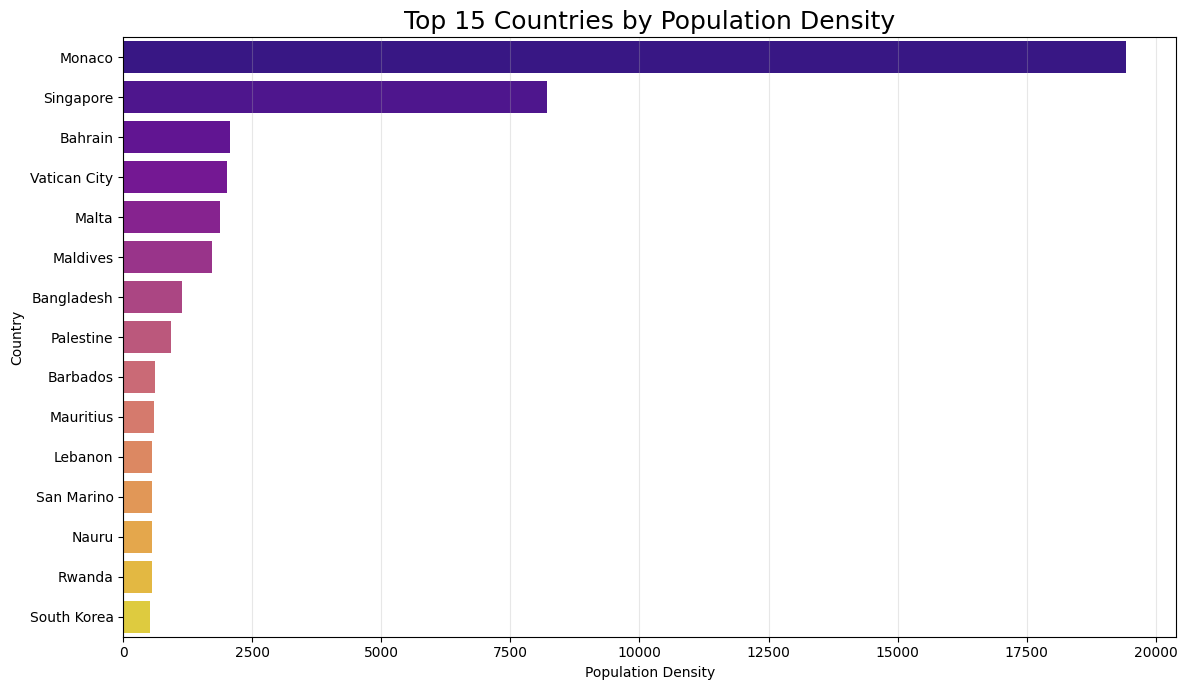

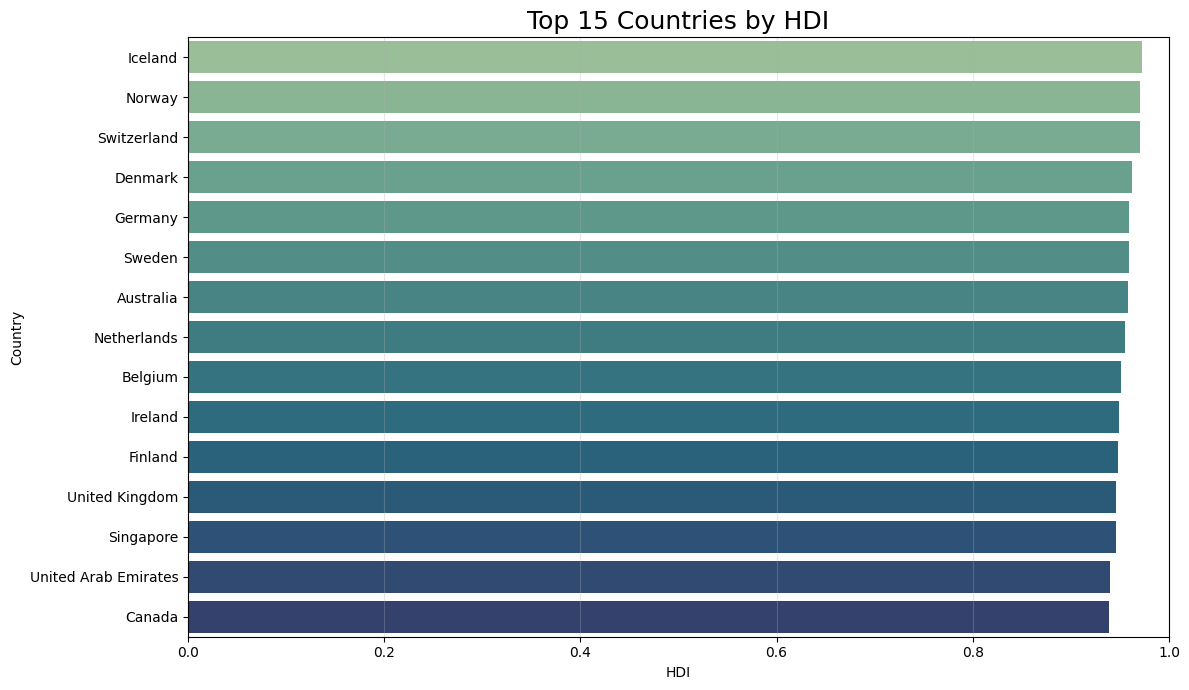

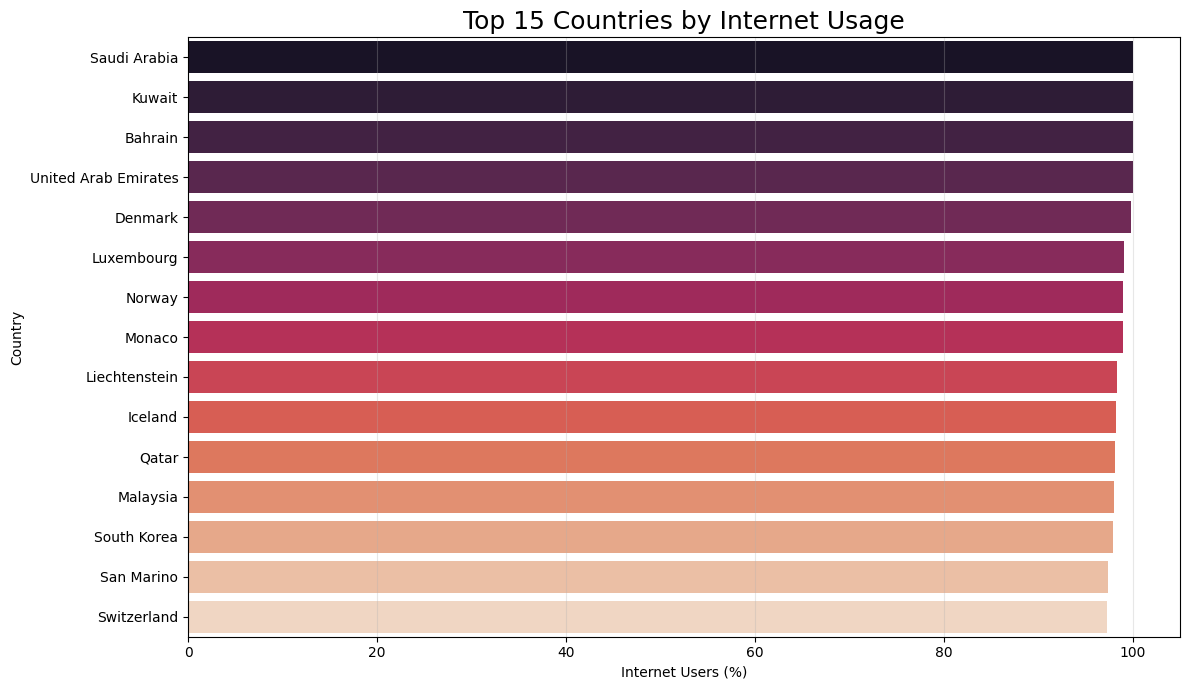

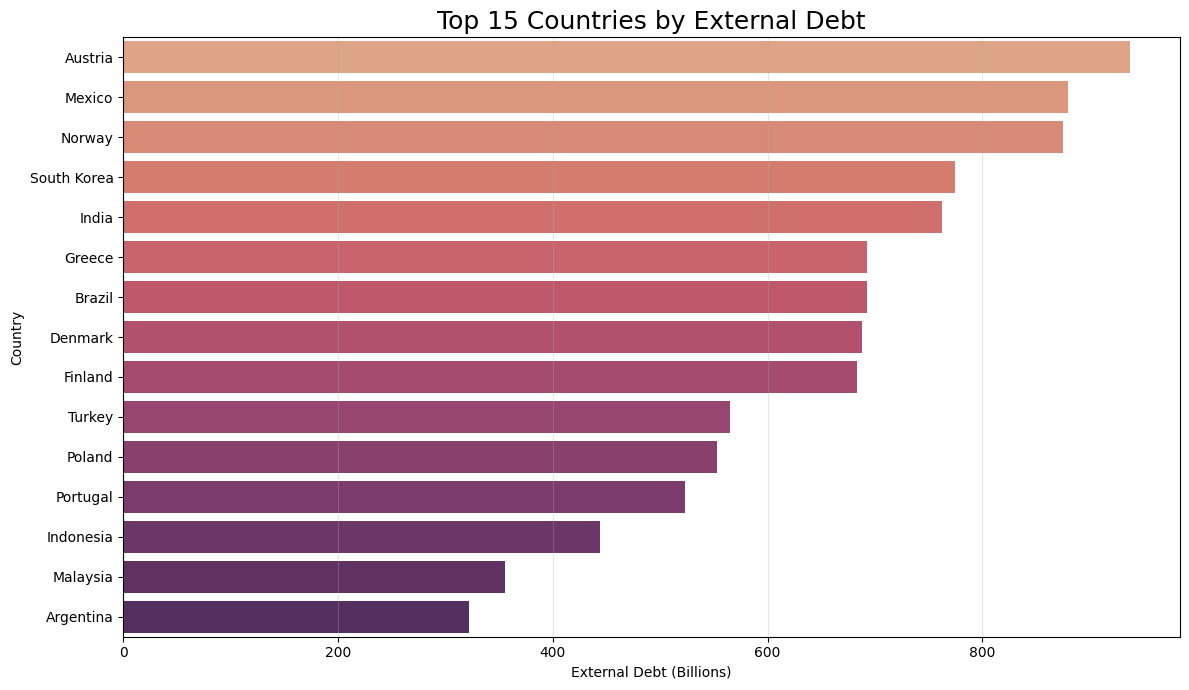

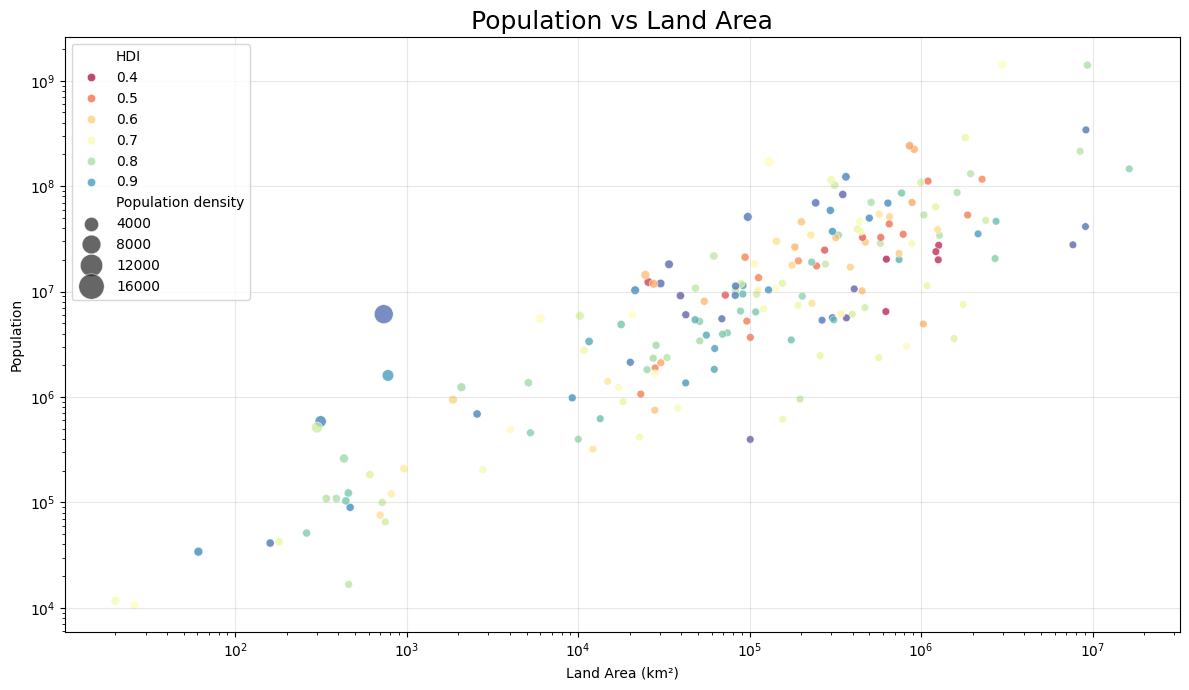

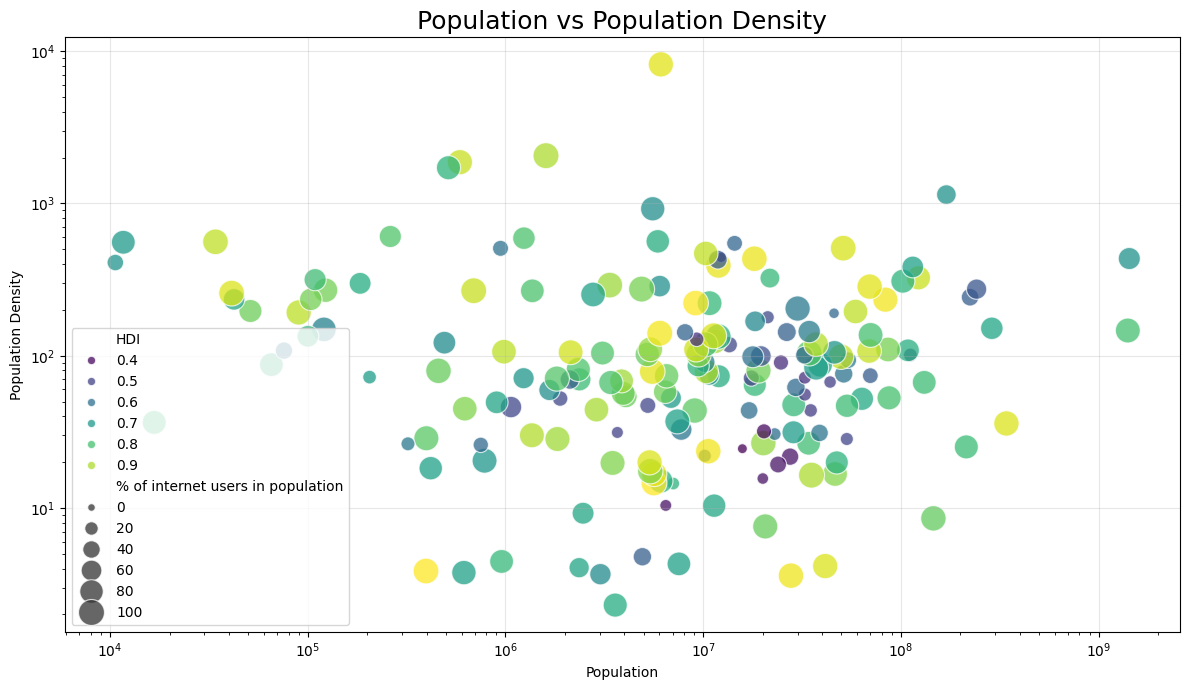

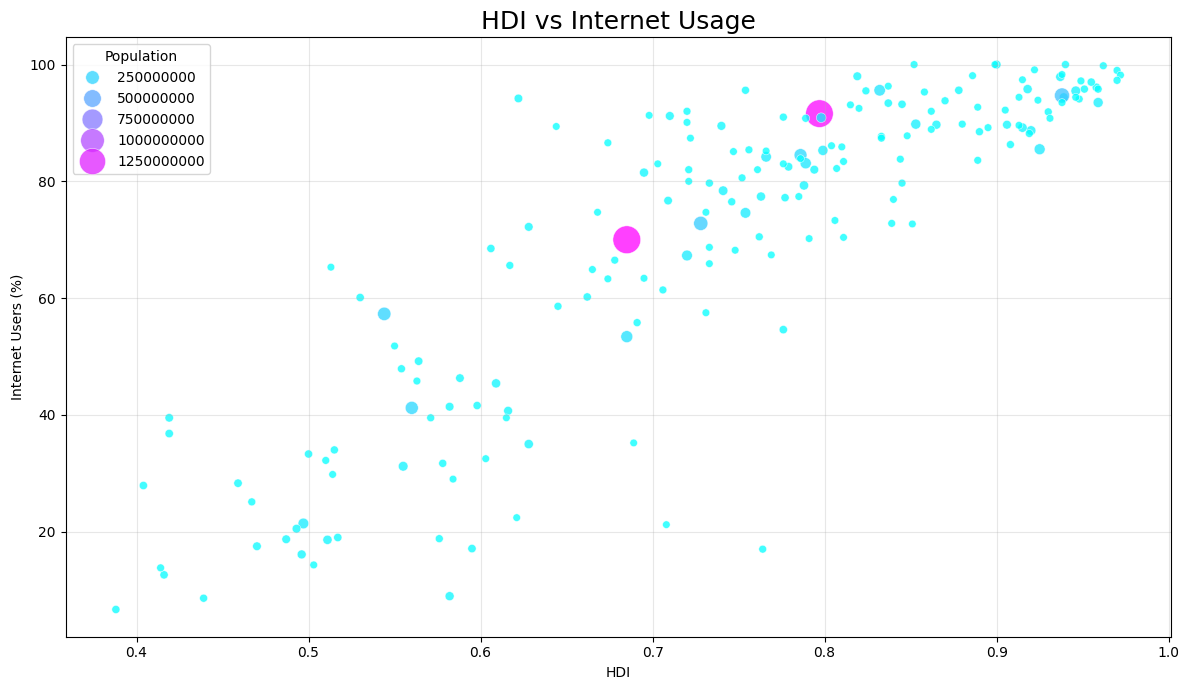

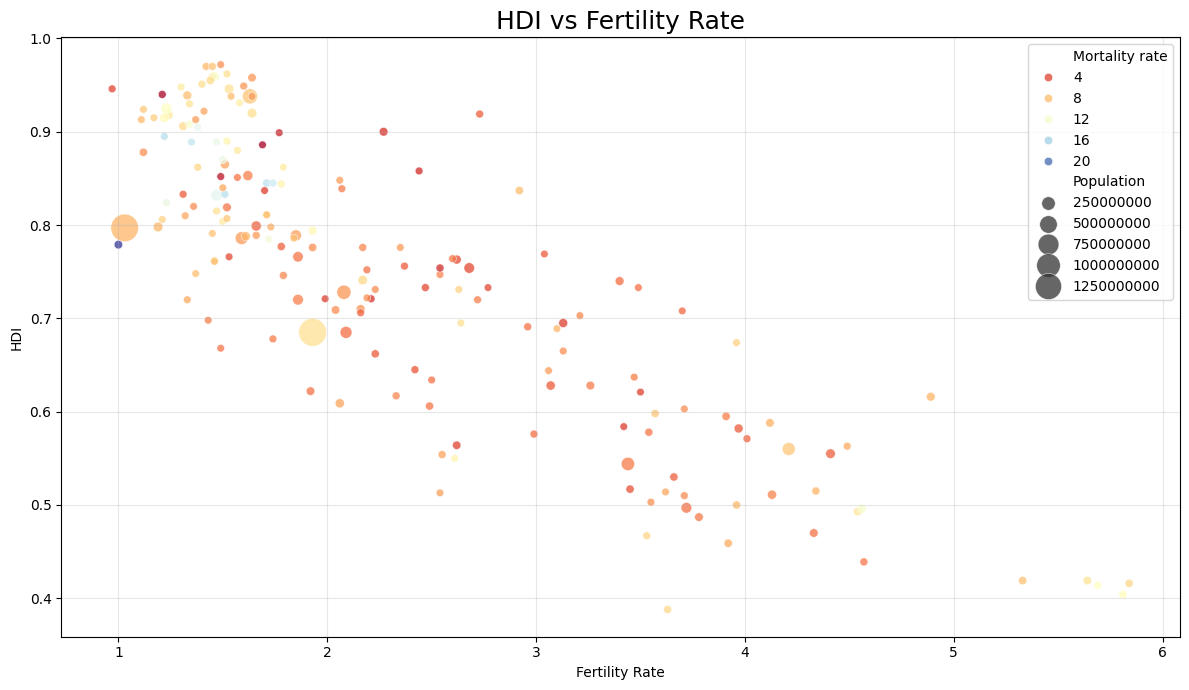

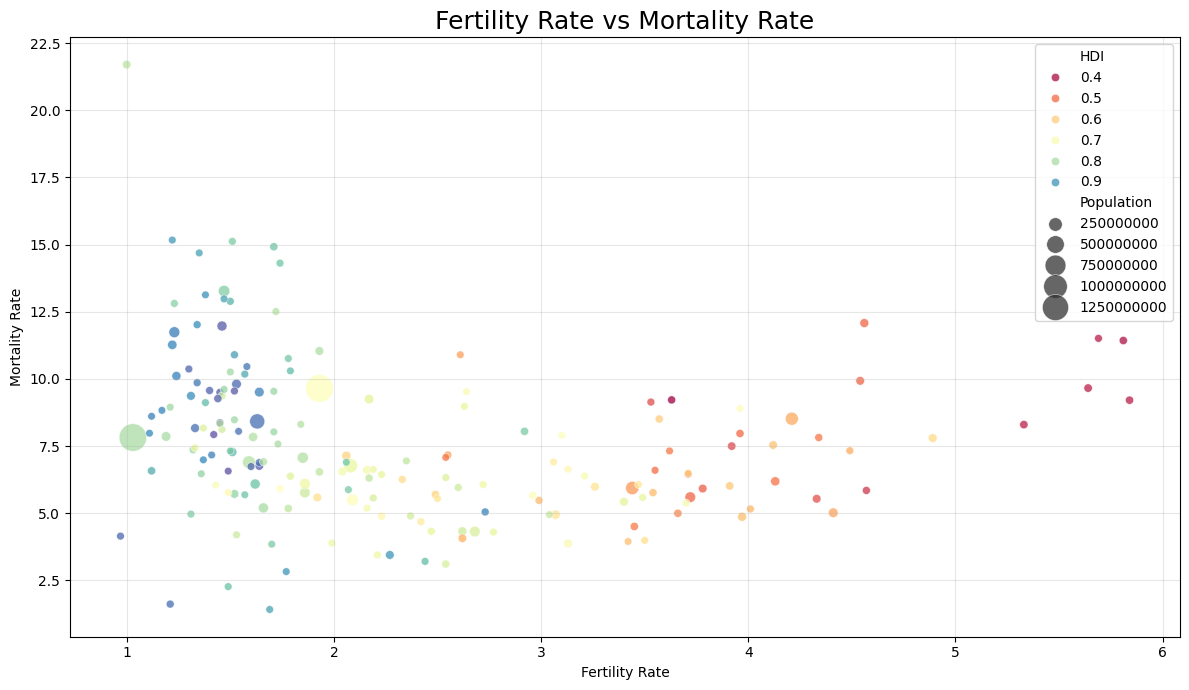

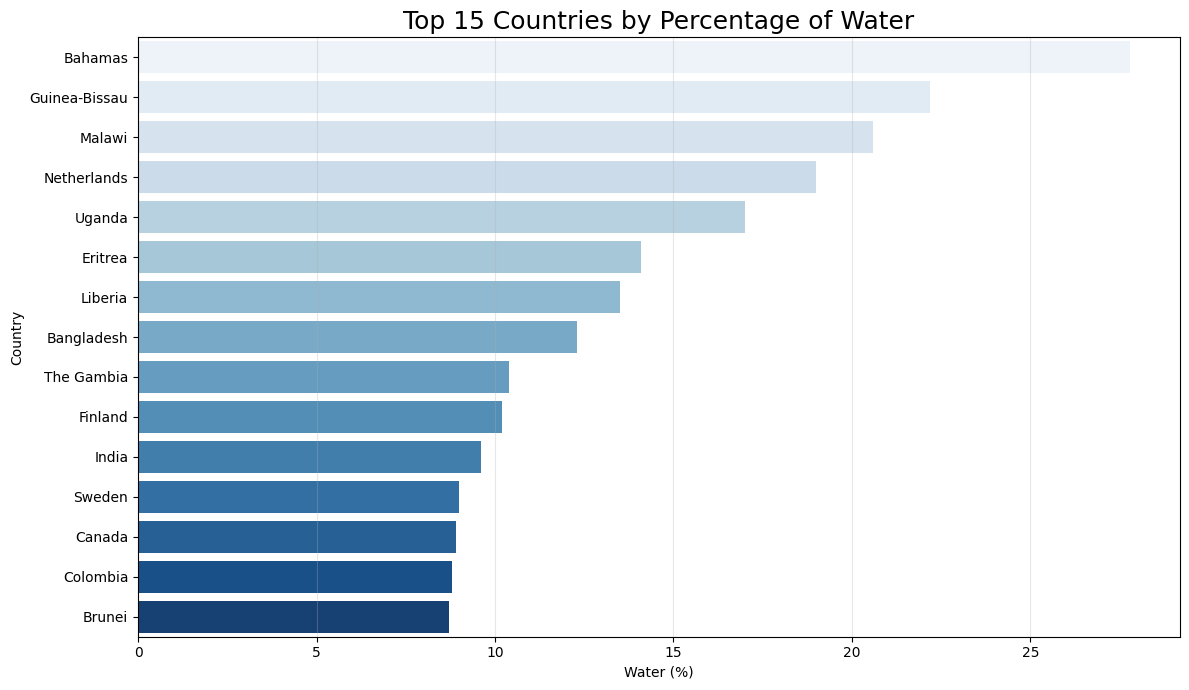

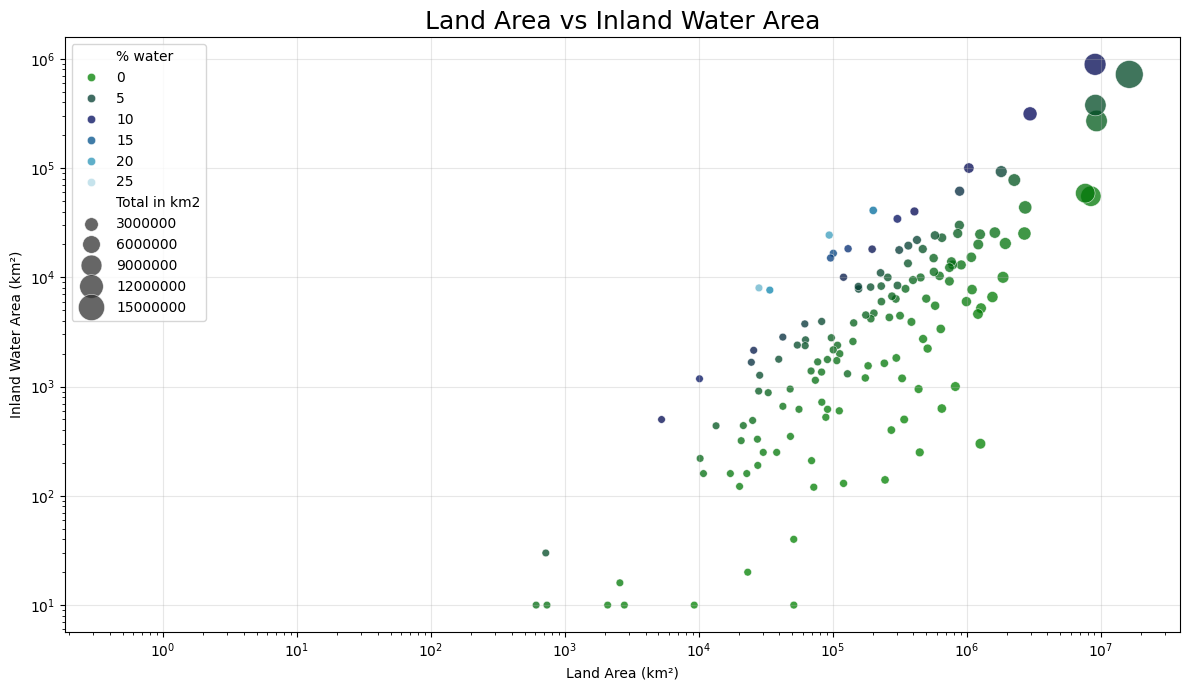

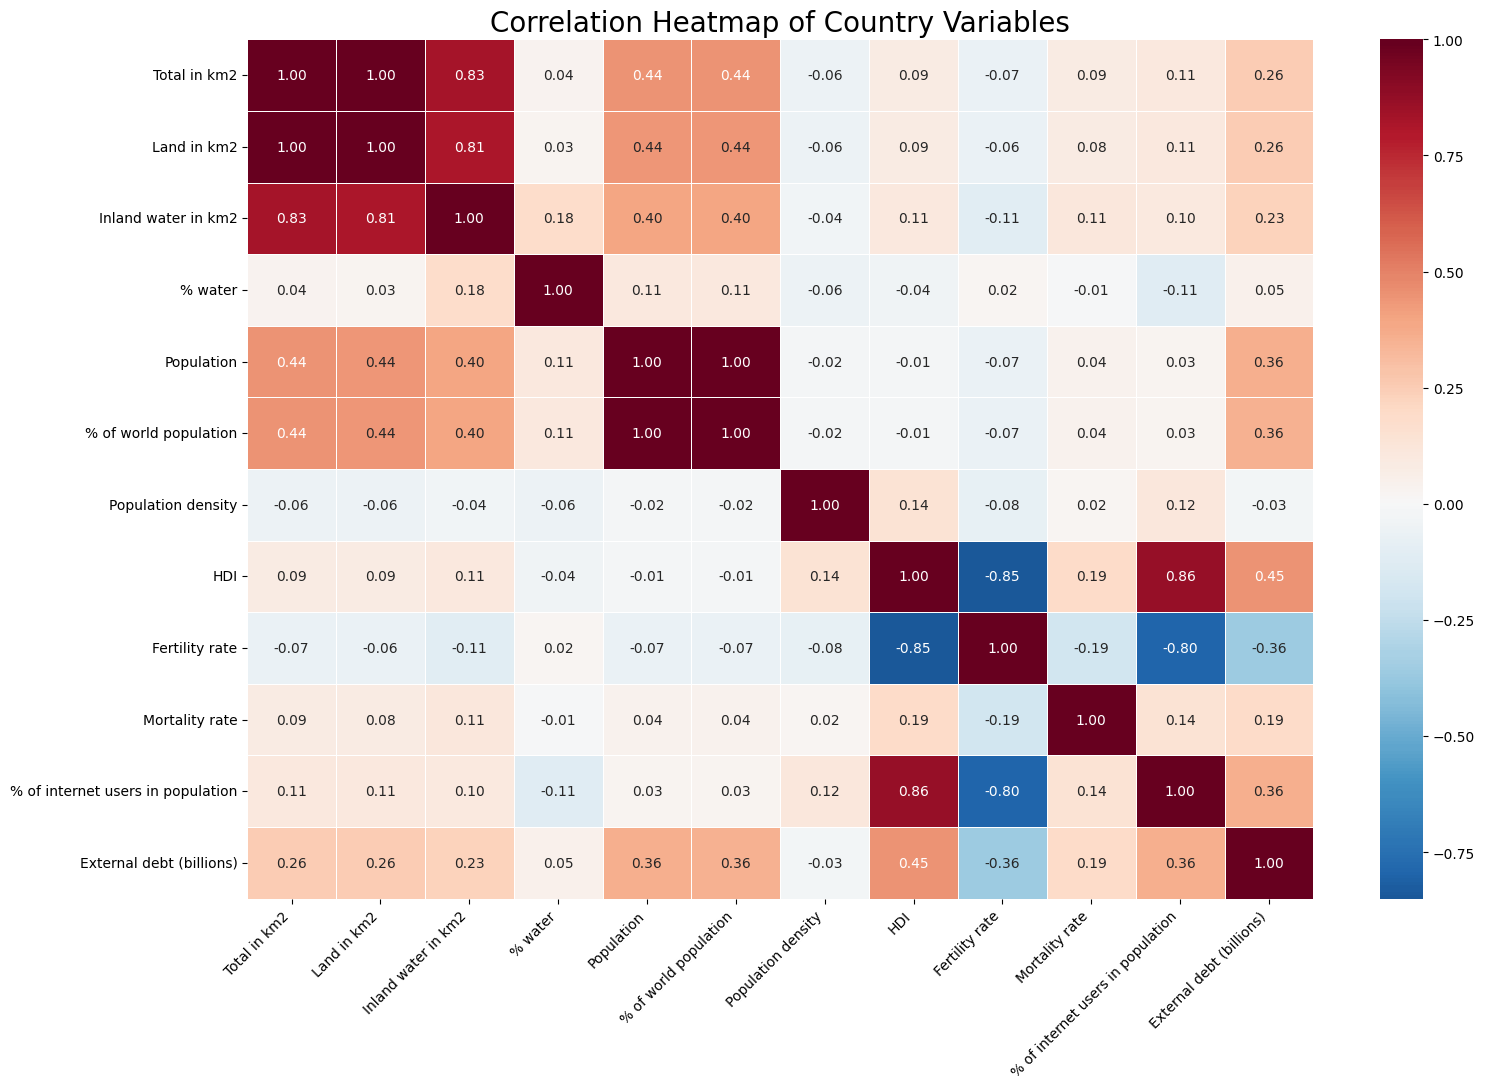

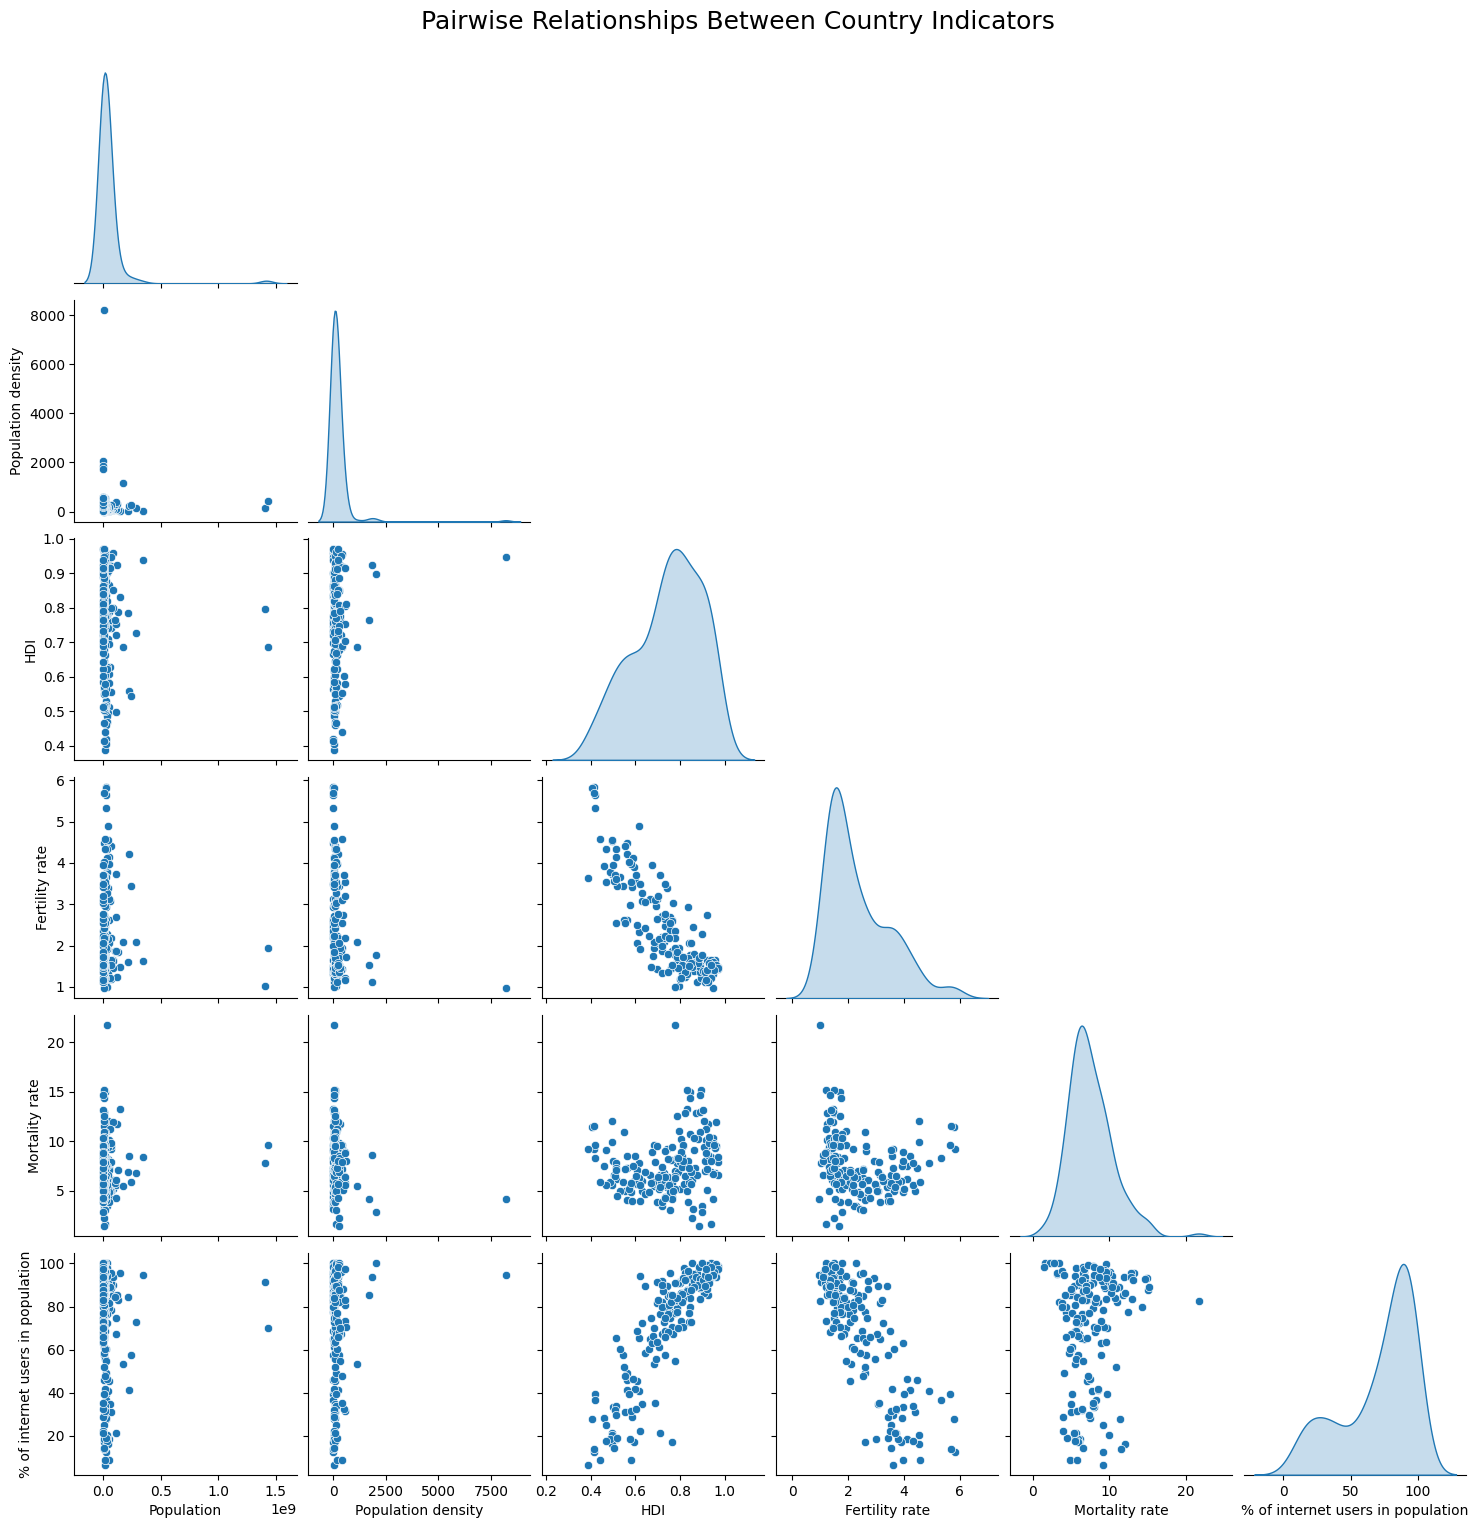

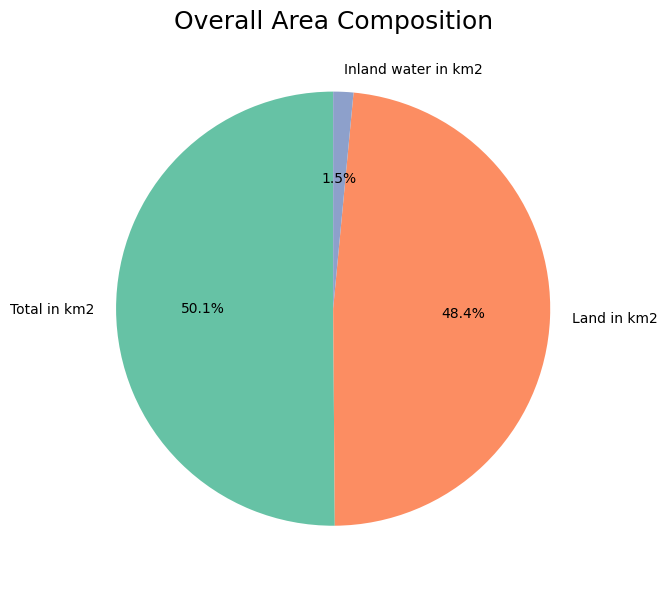

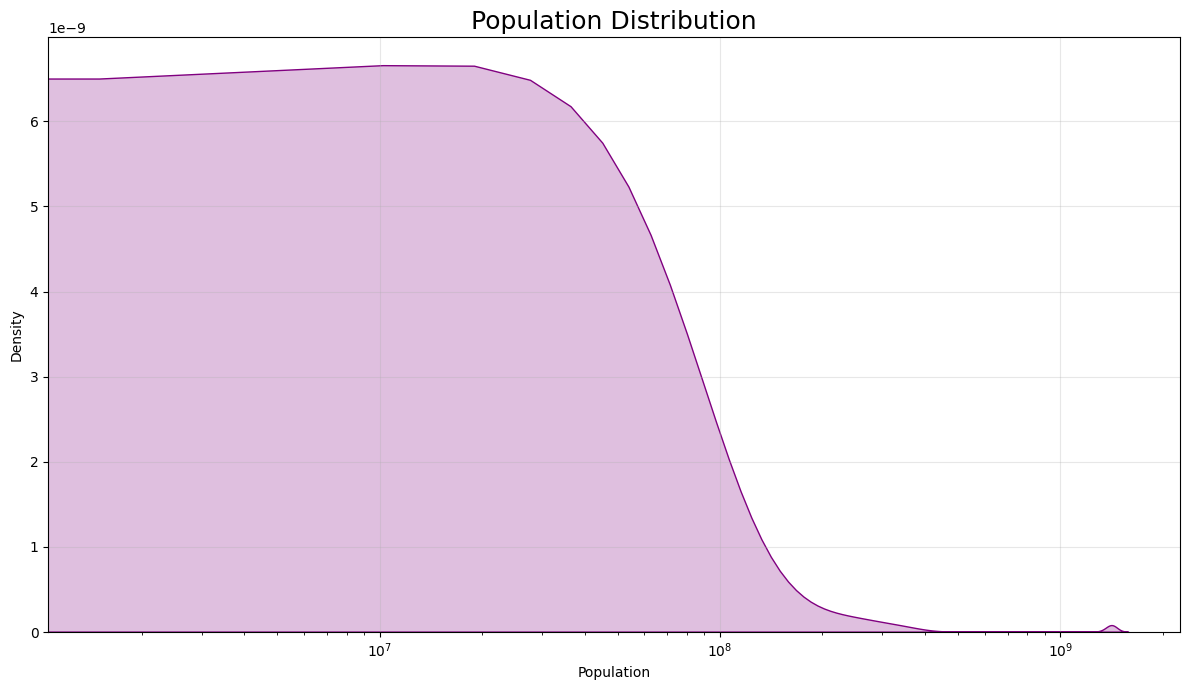

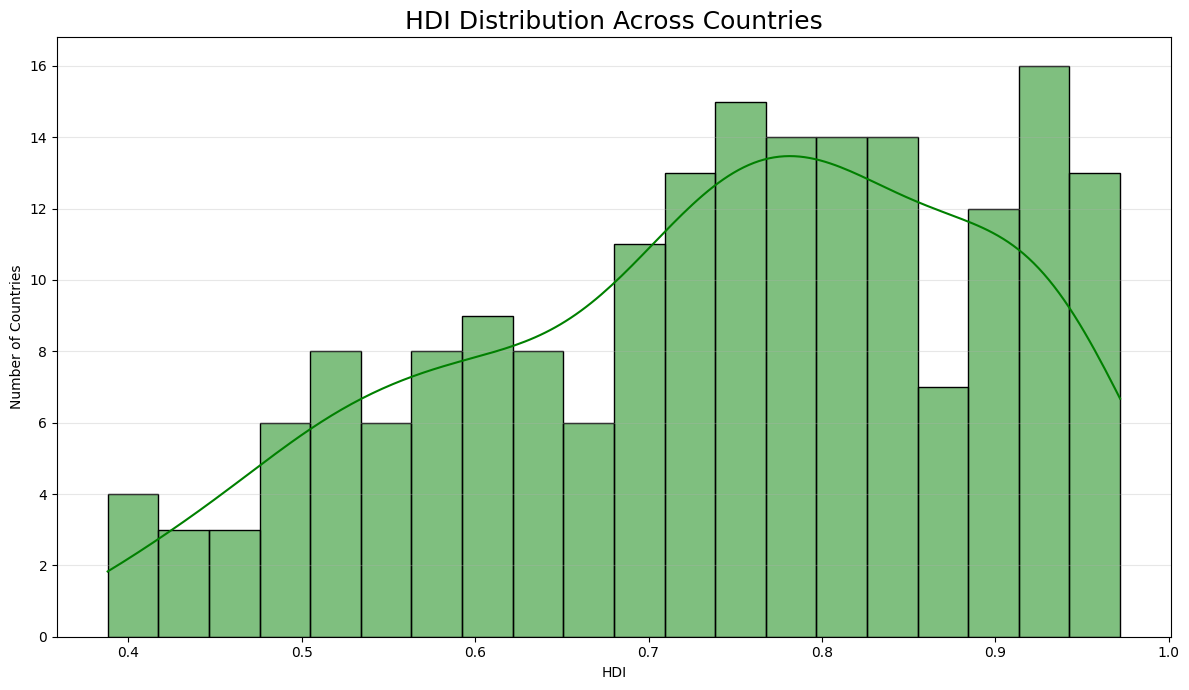

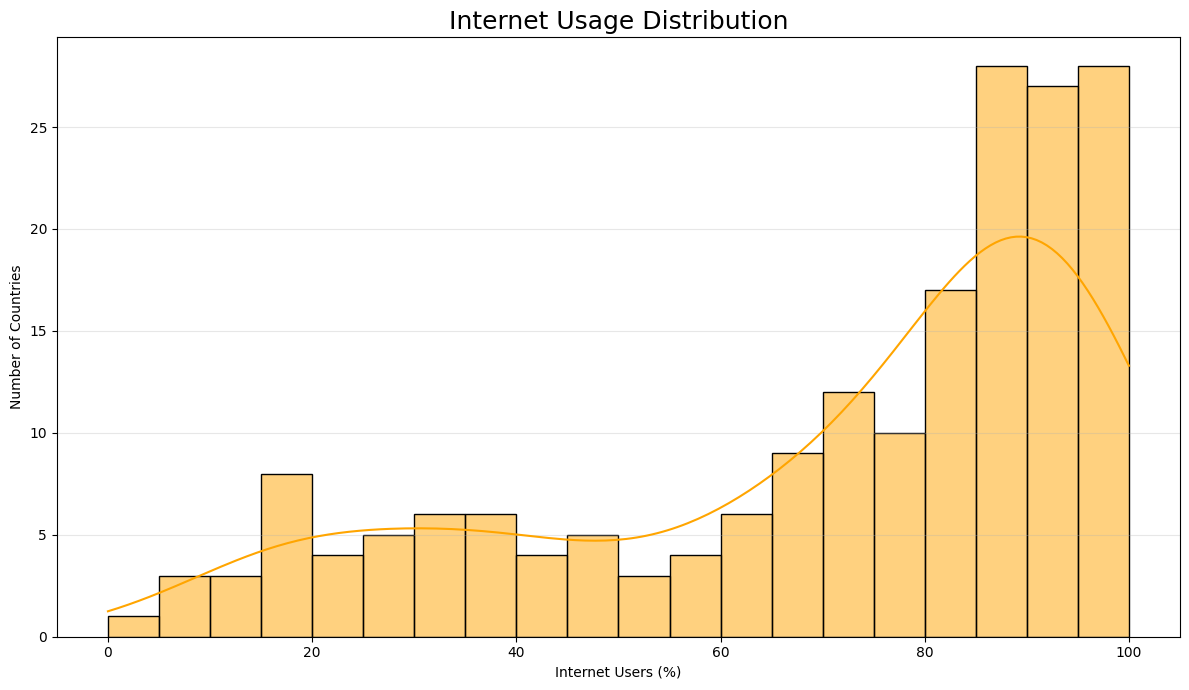

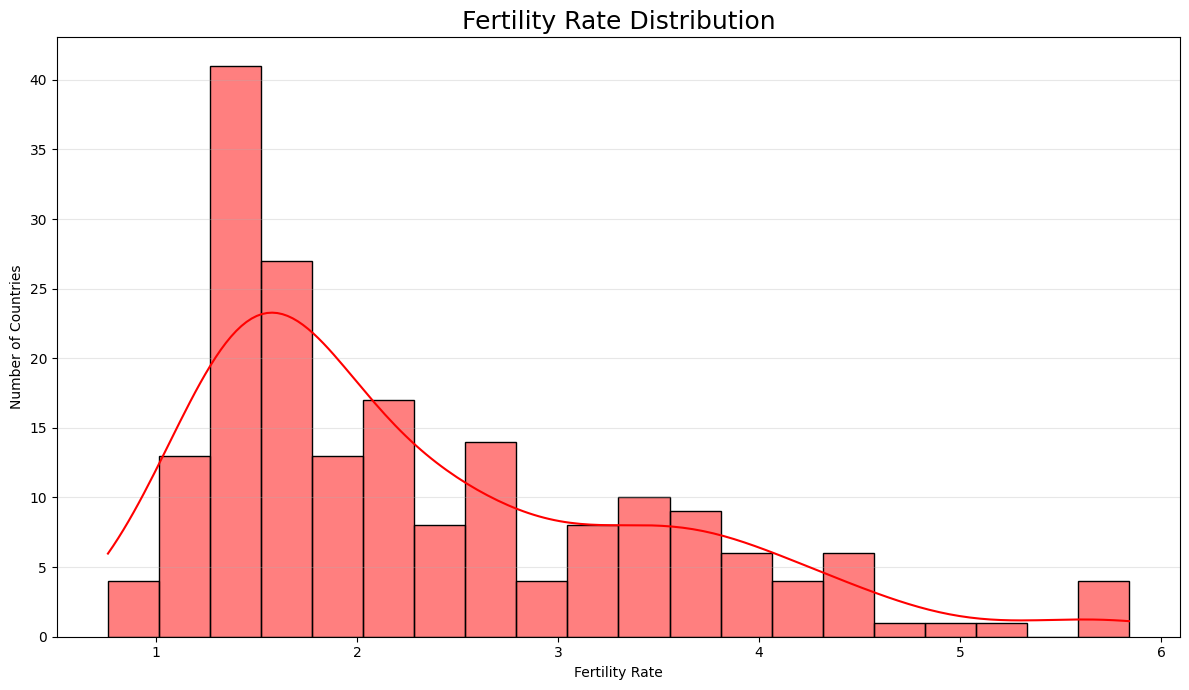

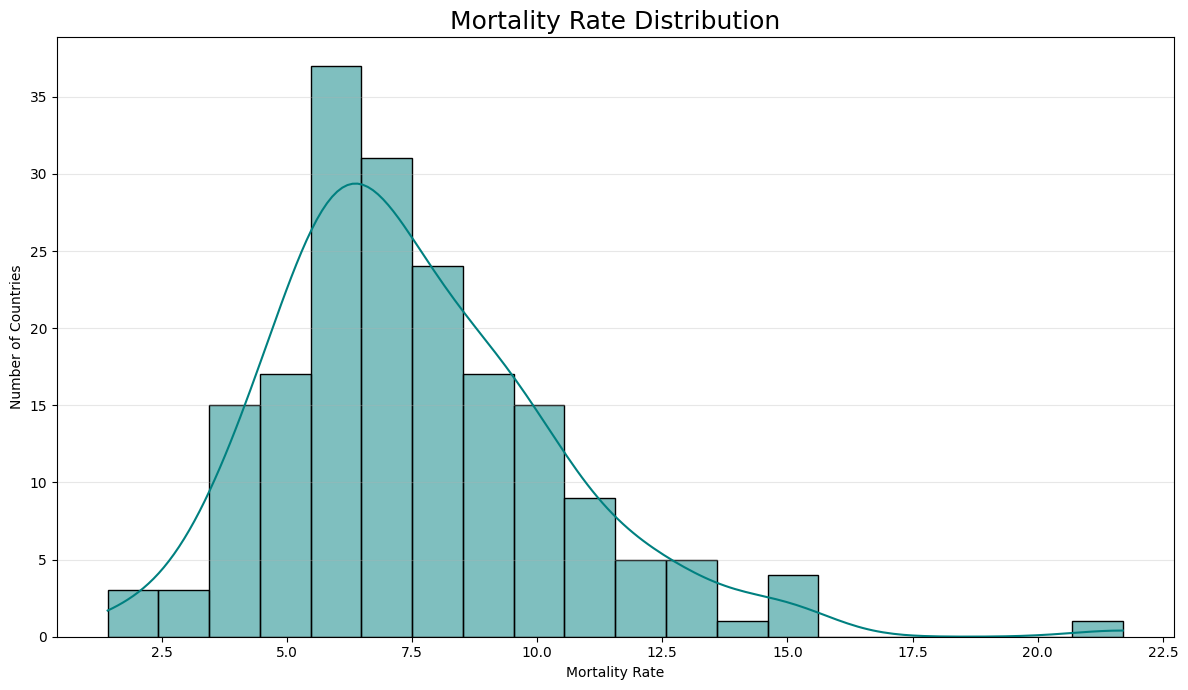

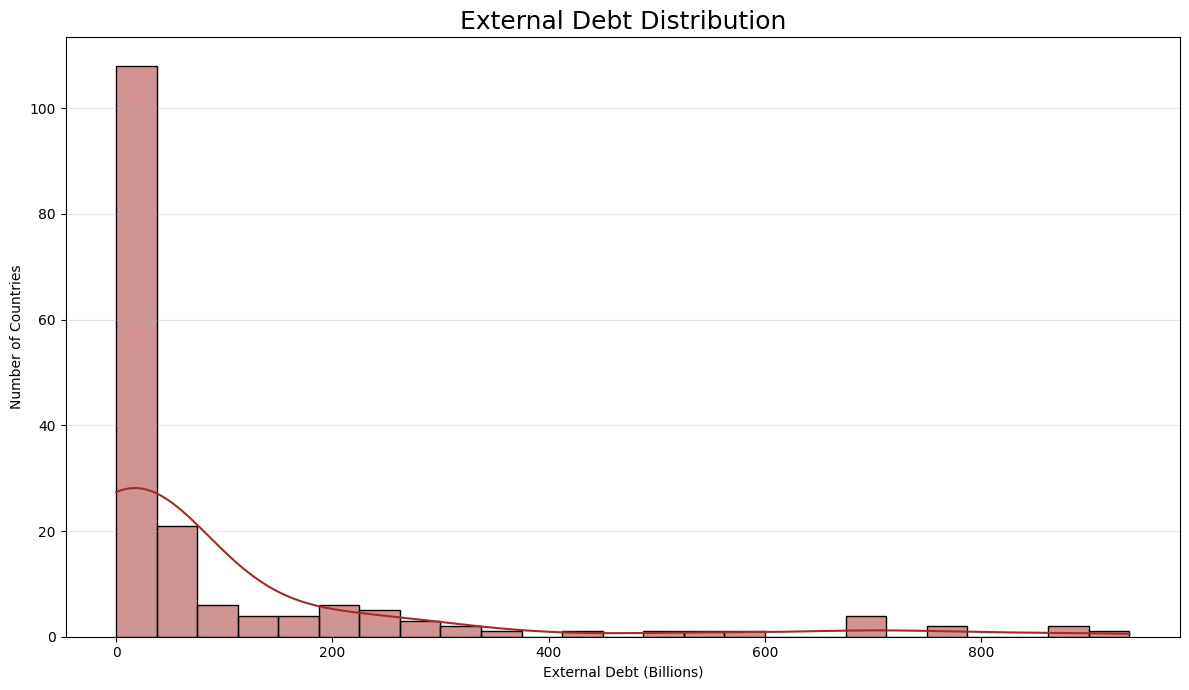

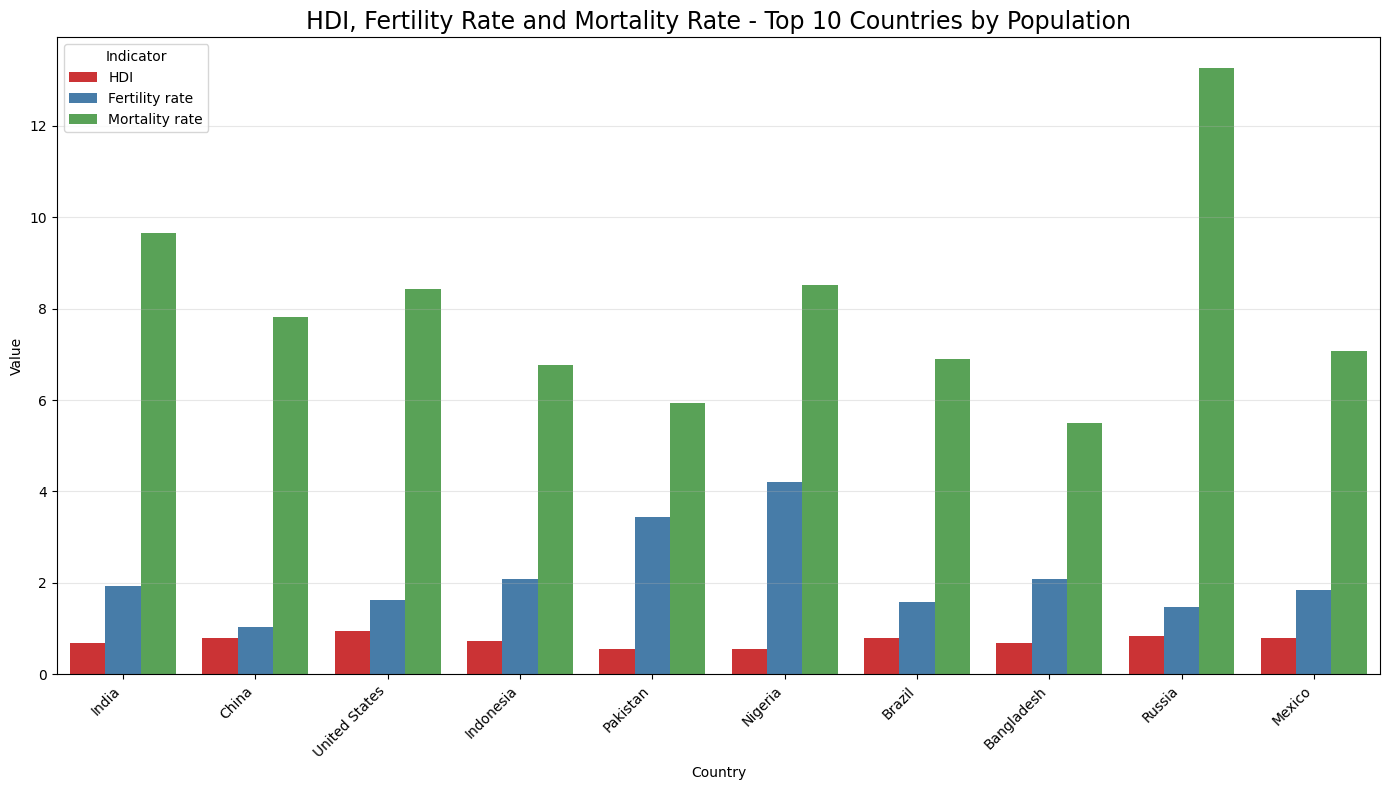


NUMERICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
Total in km2,195.0,6.850936e+05,1.909728e+06,0.440,2.308250e+04,1.184840e+05,5.092450e+05,1.709825e+07
Land in km2,194.0,6.646920e+05,1.840054e+06,0.440,2.290250e+04,1.123250e+05,4.924125e+05,1.637687e+07
Inland water in km2,194.0,2.059549e+04,9.105349e+04,0.000,1.150000e+01,1.592500e+03,9.022500e+03,8.911630e+05
% water,194.0,2.567784e+00,4.103184e+00,0.000,1.000000e-01,1.400000e+00,3.175000e+00,2.780000e+01
Population,194.0,4.139528e+07,1.491410e+08,882.000,1.846638e+06,9.244136e+06,3.187902e+07,1.429404e+09
% of world population,194.0,4.960134e-01,1.805684e+00,0.000,2.000000e-02,1.000000e-01,4.000000e-01,1.730000e+01
Population density,194.0,3.173567e+02,1.524826e+03,2.300,3.350250e+01,8.657000e+01,2.022025e+02,1.942850e+04
HDI,190.0,7.398947e-01,1.506550e-01,0.388,6.235000e-01,7.615000e-01,8.567500e-01,9.720000e-01
Fertility rate,191.0,2.349110e+00,1.113958e+00,0.760,1.490000e+00,1.930000e+00,3.085000e+00,5.840000e+00
Mortality rate,187.0,7.557166e+00,2.877799e+00,1.420,5.680000e+00,6.990000e+00,9.235000e+00,2.170000e+01



Visualization completed successfully!


In [13]:
# Optional: better display
pd.set_option("display.max_columns", None)

# -----------------------------
# 2. Dataset Overview
# -----------------------------

print("Dataset Shape:")
print(df.shape)

print("\nDataset Columns:")
print(df.columns)

print("\nFirst 5 Rows:")
display(df.head())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

# -----------------------------
# 3. Copy Dataset
# -----------------------------

df_viz = df.copy()

# -----------------------------
# 4. Convert Numeric Columns
# -----------------------------

numeric_columns = [
    'Total in km2',
    'Land in km2',
    'Inland water in km2',
    '% water',
    'Population',
    '% of world population',
    'Population density',
    'HDI',
    'Fertility rate',
    'Mortality rate',
    '% of internet users in population',
    'External debt (billions)'
]

for col in numeric_columns:
    df_viz[col] = pd.to_numeric(df_viz[col], errors='coerce')

print("\nNumeric Data Types:")
print(df_viz[numeric_columns].dtypes)

# ============================================================
# 5. HISTOGRAMS - Numerical Distributions
# ============================================================

for col in numeric_columns:

    plt.figure(figsize=(10, 6))

    sns.histplot(
        data=df_viz,
        x=col,
        bins=30,
        kde=True,
        color=np.random.rand(3)
    )

    plt.title(f'Distribution of {col}', fontsize=16)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)

    plt.xticks(rotation=30)
    plt.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()


# ============================================================
# 6. BOX PLOTS - Detect Outliers
# ============================================================

for col in numeric_columns:

    plt.figure(figsize=(10, 5))

    sns.boxplot(
        x=df_viz[col],
        color=np.random.rand(3)
    )

    plt.title(f'Box Plot of {col}', fontsize=16)
    plt.xlabel(col)

    plt.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()


# ============================================================
# 7. TOP 15 COUNTRIES BY POPULATION
# ============================================================

top_population = (
    df_viz
    .sort_values('Population', ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_population,
    x='Population',
    y='Country name',
    hue='Country name',
    palette='viridis',
    legend=False
)

plt.title('Top 15 Countries by Population', fontsize=18)
plt.xlabel('Population')
plt.ylabel('Country')

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 8. TOP 15 COUNTRIES BY LAND AREA
# ============================================================

top_land = (
    df_viz
    .sort_values('Land in km2', ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_land,
    x='Land in km2',
    y='Country name',
    hue='Country name',
    palette='magma',
    legend=False
)

plt.title('Top 15 Countries by Land Area', fontsize=18)
plt.xlabel('Land Area (km²)')
plt.ylabel('Country')

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 9. TOP 15 COUNTRIES BY TOTAL AREA
# ============================================================

top_area = (
    df_viz
    .sort_values('Total in km2', ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_area,
    x='Total in km2',
    y='Country name',
    hue='Country name',
    palette='coolwarm',
    legend=False
)

plt.title('Top 15 Countries by Total Area', fontsize=18)
plt.xlabel('Total Area (km²)')
plt.ylabel('Country')

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 10. TOP 15 COUNTRIES BY POPULATION DENSITY
# ============================================================

top_density = (
    df_viz
    .sort_values('Population density', ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_density,
    x='Population density',
    y='Country name',
    hue='Country name',
    palette='plasma',
    legend=False
)

plt.title('Top 15 Countries by Population Density', fontsize=18)
plt.xlabel('Population Density')
plt.ylabel('Country')

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 11. TOP 15 COUNTRIES BY HDI
# ============================================================

top_hdi = (
    df_viz
    .sort_values('HDI', ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_hdi,
    x='HDI',
    y='Country name',
    hue='Country name',
    palette='crest',
    legend=False
)

plt.title('Top 15 Countries by HDI', fontsize=18)
plt.xlabel('HDI')
plt.ylabel('Country')

plt.xlim(0, 1)

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 12. TOP 15 COUNTRIES BY INTERNET USERS
# ============================================================

top_internet = (
    df_viz
    .sort_values('% of internet users in population', ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_internet,
    x='% of internet users in population',
    y='Country name',
    hue='Country name',
    palette='rocket',
    legend=False
)

plt.title('Top 15 Countries by Internet Usage', fontsize=18)
plt.xlabel('Internet Users (%)')
plt.ylabel('Country')

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 13. TOP 15 COUNTRIES BY EXTERNAL DEBT
# ============================================================

top_debt = (
    df_viz
    .sort_values('External debt (billions)', ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_debt,
    x='External debt (billions)',
    y='Country name',
    hue='Country name',
    palette='flare',
    legend=False
)

plt.title('Top 15 Countries by External Debt', fontsize=18)
plt.xlabel('External Debt (Billions)')
plt.ylabel('Country')

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 14. POPULATION VS LAND AREA
# ============================================================

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df_viz,
    x='Land in km2',
    y='Population',
    size='Population density',
    hue='HDI',
    palette='Spectral',
    sizes=(30, 400),
    alpha=0.75
)

plt.title('Population vs Land Area', fontsize=18)
plt.xlabel('Land Area (km²)')
plt.ylabel('Population')

plt.xscale('log')
plt.yscale('log')

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 15. POPULATION VS POPULATION DENSITY
# ============================================================

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df_viz,
    x='Population',
    y='Population density',
    hue='HDI',
    size='% of internet users in population',
    palette='viridis',
    sizes=(30, 350),
    alpha=0.75
)

plt.title('Population vs Population Density', fontsize=18)
plt.xlabel('Population')
plt.ylabel('Population Density')

plt.xscale('log')
plt.yscale('log')

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 16. HDI VS INTERNET USAGE
# ============================================================

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df_viz,
    x='HDI',
    y='% of internet users in population',
    hue='Population',
    size='Population',
    palette='cool',
    sizes=(30, 400),
    alpha=0.75
)

plt.title('HDI vs Internet Usage', fontsize=18)
plt.xlabel('HDI')
plt.ylabel('Internet Users (%)')

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 17. HDI VS FERTILITY RATE
# ============================================================

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df_viz,
    x='Fertility rate',
    y='HDI',
    hue='Mortality rate',
    size='Population',
    palette='RdYlBu',
    sizes=(30, 400),
    alpha=0.75
)

plt.title('HDI vs Fertility Rate', fontsize=18)
plt.xlabel('Fertility Rate')
plt.ylabel('HDI')

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 18. FERTILITY RATE VS MORTALITY RATE
# ============================================================

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df_viz,
    x='Fertility rate',
    y='Mortality rate',
    hue='HDI',
    palette='Spectral',
    size='Population',
    sizes=(30, 400),
    alpha=0.75
)

plt.title('Fertility Rate vs Mortality Rate', fontsize=18)
plt.xlabel('Fertility Rate')
plt.ylabel('Mortality Rate')

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 19. WATER PERCENTAGE BY TOP 15 COUNTRIES
# ============================================================

top_water = (
    df_viz
    .sort_values('% water', ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_water,
    x='% water',
    y='Country name',
    hue='Country name',
    palette='Blues',
    legend=False
)

plt.title('Top 15 Countries by Percentage of Water', fontsize=18)
plt.xlabel('Water (%)')
plt.ylabel('Country')

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 20. LAND AREA VS WATER AREA
# ============================================================

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df_viz,
    x='Land in km2',
    y='Inland water in km2',
    hue='% water',
    palette='ocean',
    size='Total in km2',
    sizes=(30, 400),
    alpha=0.75
)

plt.title('Land Area vs Inland Water Area', fontsize=18)
plt.xlabel('Land Area (km²)')
plt.ylabel('Inland Water Area (km²)')

plt.xscale('log')
plt.yscale('log')

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 21. CORRELATION HEATMAP
# ============================================================

correlation = df_viz[numeric_columns].corr()

plt.figure(figsize=(16, 11))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5
)

plt.title('Correlation Heatmap of Country Variables', fontsize=20)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


# ============================================================
# 22. PAIRPLOT
# ============================================================

pair_columns = [
    'Population',
    'Population density',
    'HDI',
    'Fertility rate',
    'Mortality rate',
    '% of internet users in population'
]

pair_df = df_viz[pair_columns].dropna()

sns.pairplot(
    pair_df,
    diag_kind='kde',
    corner=True,
    palette='husl'
)

plt.suptitle(
    'Pairwise Relationships Between Country Indicators',
    y=1.02,
    fontsize=18
)

plt.show()


# ============================================================
# 23. AREA COMPARISON
# ============================================================

area_columns = [
    'Total in km2',
    'Land in km2',
    'Inland water in km2'
]

area_data = df_viz[area_columns].sum()

plt.figure(figsize=(10, 6))

plt.pie(
    area_data.values,
    labels=area_data.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('Set2', len(area_data))
)

plt.title('Overall Area Composition', fontsize=18)

plt.tight_layout()
plt.show()


# ============================================================
# 24. POPULATION DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 7))

sns.kdeplot(
    data=df_viz,
    x='Population',
    fill=True,
    color='purple'
)

plt.title('Population Distribution', fontsize=18)
plt.xlabel('Population')
plt.ylabel('Density')

plt.xscale('log')

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 25. HDI DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 7))

sns.histplot(
    data=df_viz,
    x='HDI',
    bins=20,
    kde=True,
    color='green'
)

plt.title('HDI Distribution Across Countries', fontsize=18)
plt.xlabel('HDI')
plt.ylabel('Number of Countries')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 26. INTERNET USAGE DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 7))

sns.histplot(
    data=df_viz,
    x='% of internet users in population',
    bins=20,
    kde=True,
    color='orange'
)

plt.title('Internet Usage Distribution', fontsize=18)
plt.xlabel('Internet Users (%)')
plt.ylabel('Number of Countries')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 27. FERTILITY RATE DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 7))

sns.histplot(
    data=df_viz,
    x='Fertility rate',
    bins=20,
    kde=True,
    color='red'
)

plt.title('Fertility Rate Distribution', fontsize=18)
plt.xlabel('Fertility Rate')
plt.ylabel('Number of Countries')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 28. MORTALITY RATE DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 7))

sns.histplot(
    data=df_viz,
    x='Mortality rate',
    bins=20,
    kde=True,
    color='teal'
)

plt.title('Mortality Rate Distribution', fontsize=18)
plt.xlabel('Mortality Rate')
plt.ylabel('Number of Countries')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 29. EXTERNAL DEBT DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 7))

sns.histplot(
    data=df_viz,
    x='External debt (billions)',
    bins=25,
    kde=True,
    color='brown'
)

plt.title('External Debt Distribution', fontsize=18)
plt.xlabel('External Debt (Billions)')
plt.ylabel('Number of Countries')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 30. TOP 10 COUNTRIES - COMBINED INDICATOR VIEW
# ============================================================

top10 = (
    df_viz
    .sort_values('Population', ascending=False)
    .head(10)
    .copy()
)

top10_melt = top10[
    [
        'Country name',
        'HDI',
        'Fertility rate',
        'Mortality rate'
    ]
].melt(
    id_vars='Country name',
    var_name='Indicator',
    value_name='Value'
)

plt.figure(figsize=(14, 8))

sns.barplot(
    data=top10_melt,
    x='Country name',
    y='Value',
    hue='Indicator',
    palette='Set1'
)

plt.title(
    'HDI, Fertility Rate and Mortality Rate - Top 10 Countries by Population',
    fontsize=17
)

plt.xlabel('Country')
plt.ylabel('Value')

plt.xticks(rotation=45, ha='right')

plt.grid(axis='y', alpha=0.3)

plt.legend(title='Indicator')

plt.tight_layout()
plt.show()


# ============================================================
# 31. FINAL NUMERICAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("NUMERICAL SUMMARY")
print("=" * 70)

display(
    df_viz[numeric_columns].describe().T
)

print("\nVisualization completed successfully!")

## Feature engineering

Dataset Shape:
(195, 13)

Columns:
['Country name', 'Total in km2', 'Land in km2', 'Inland water in km2', '% water', 'Population', '% of world population', 'Population density', 'HDI', 'Fertility rate', 'Mortality rate', '% of internet users in population', 'External debt (billions)']

First 5 Rows:


,Country name,Total in km2,Land in km2,Inland water in km2,% water,Population,% of world population,Population density,HDI,Fertility rate,Mortality rate,% of internet users in population,External debt (billions)
0,Russia,17098246.0,16376870.0,721380.0,4.2,1.460283e+08,1.8,8.54,0.832,1.47,13.27,95.6,299.0637
1,Canada,9984670.0,9093507.0,891163.0,8.9,4.141706e+07,0.5,4.15,0.939,1.33,8.17,94.4,"3,468.2119"
2,China,9596960.0,9326410.0,270550.0,2.8,1.404890e+09,17.0,146.39,0.797,1.03,7.82,91.6,"2,412.0799"
3,United States,9525067.0,9147593.0,377424.0,4.0,3.417849e+08,4.1,35.88,0.938,1.63,8.42,94.7,"30,196.961"
4,Brazil,8510346.0,8460415.0,55352.0,0.6,2.142120e+08,2.6,25.17,0.786,1.59,6.90,84.5,692.6895



Missing Values:
Country name                          0
Total in km2                          0
Land in km2                           1
Inland water in km2                   1
% water                               1
Population                            1
% of world population                 1
Population density                    1
HDI                                   5
Fertility rate                        4
Mortality rate                        8
% of internet users in population     6
External debt (billions)             22
dtype: int64

HDI Category Distribution:
HDI_Category
Very High    72
High         50
Medium       43
Low          25
Name: count, dtype: int64


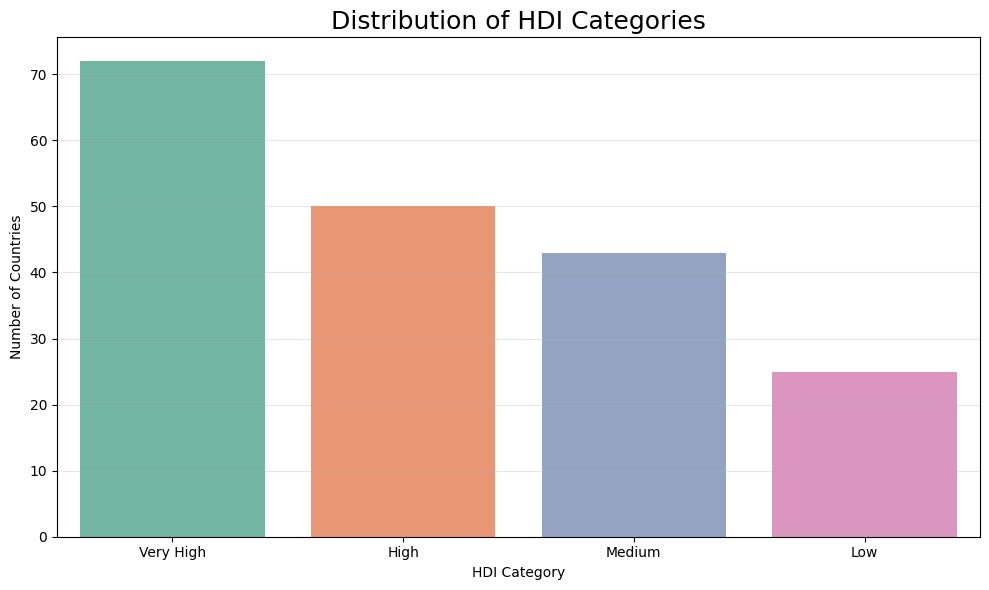


Feature Columns:
['Total in km2', 'Land in km2', 'Inland water in km2', '% water', 'Population', '% of world population', 'Population density', 'Fertility rate', 'Mortality rate', '% of internet users in population', 'External debt (billions)']

Target Column:
HDI_Category

X Shape:
(190, 11)

y Shape:
(190,)

Target Classes:
['High' 'Low' 'Medium' 'Very High']

Encoded Target:
[0 1 2 3]

Training Data Shape:
(152, 11)

Testing Data Shape:
(38, 11)

Training Target Distribution:
3    58
0    40
2    34
1    20
Name: count, dtype: int64

Testing Target Distribution:
3    14
0    10
2     9
1     5
Name: count, dtype: int64

TRAINING: Logistic Regression
Training completed!

TRAINING: Decision Tree
Training completed!

TRAINING: Random Forest
Training completed!

TRAINING: Gradient Boosting
Training completed!

TRAINING: KNN
Training completed!


MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score
0,KNN,0.7368,0.7368,0.7368,0.7368
1,Random Forest,0.7105,0.7256,0.7105,0.7145
2,Logistic Regression,0.6842,0.6917,0.6842,0.6770
3,Gradient Boosting,0.6842,0.7061,0.6842,0.6925
4,Decision Tree,0.5000,0.5409,0.5000,0.5138


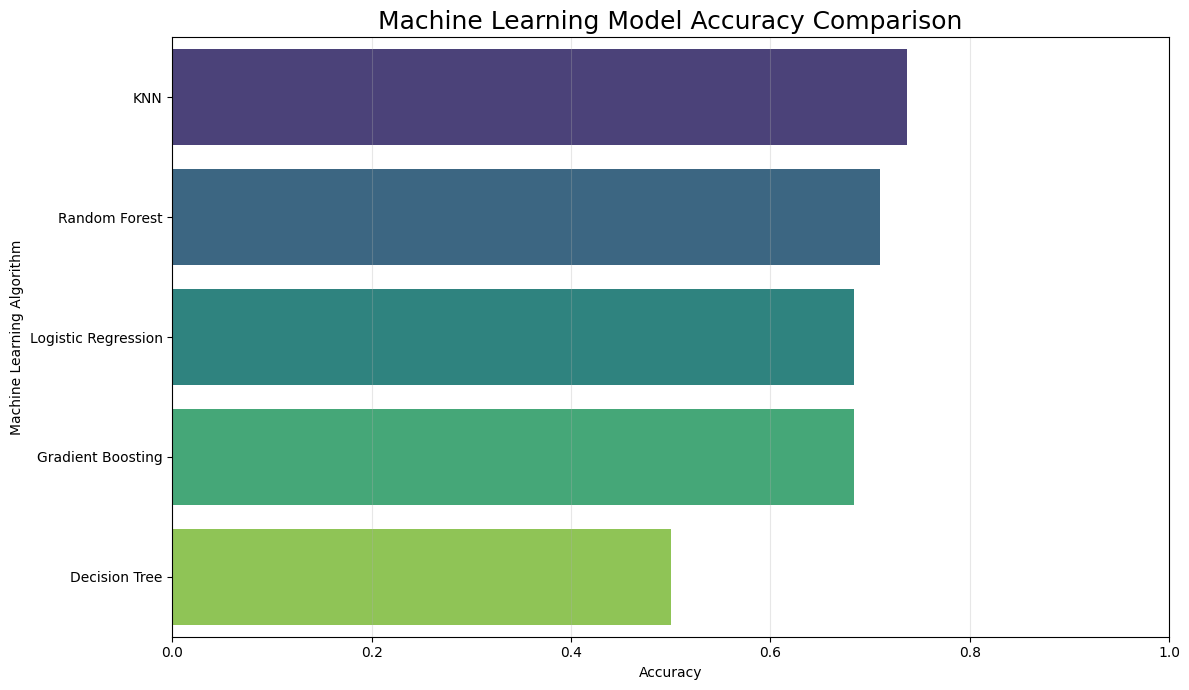

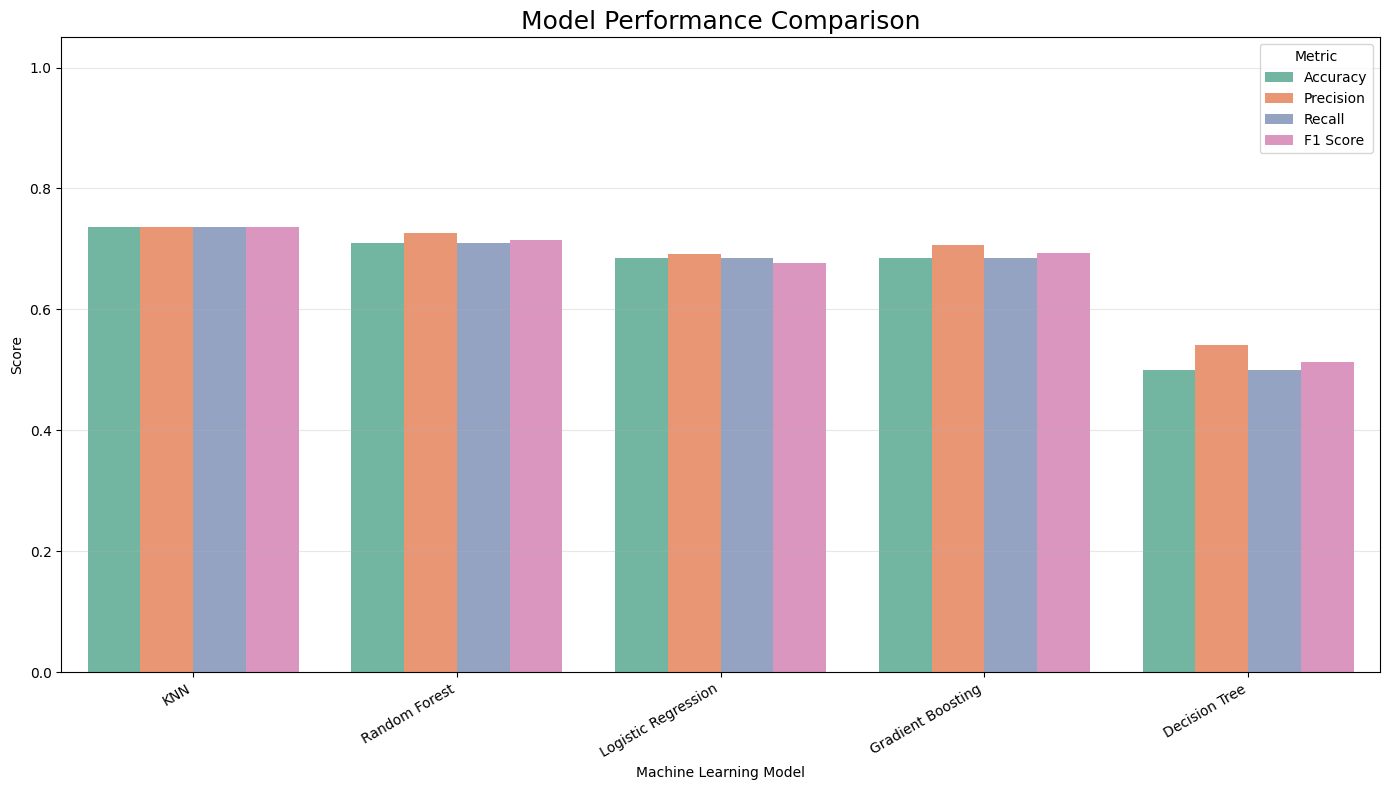



Logistic Regression
              precision    recall  f1-score   support

        High       0.50      0.40      0.44        10
         Low       1.00      0.60      0.75         5
      Medium       0.55      0.67      0.60         9
   Very High       0.81      0.93      0.87        14

    accuracy                           0.68        38
   macro avg       0.71      0.65      0.67        38
weighted avg       0.69      0.68      0.68        38



Decision Tree
              precision    recall  f1-score   support

        High       0.31      0.40      0.35        10
         Low       0.50      0.60      0.55         5
      Medium       0.25      0.22      0.24         9
   Very High       0.91      0.71      0.80        14

    accuracy                           0.50        38
   macro avg       0.49      0.48      0.48        38
weighted avg       0.54      0.50      0.51        38



Random Forest
              precision    recall  f1-score   support

        High       0.

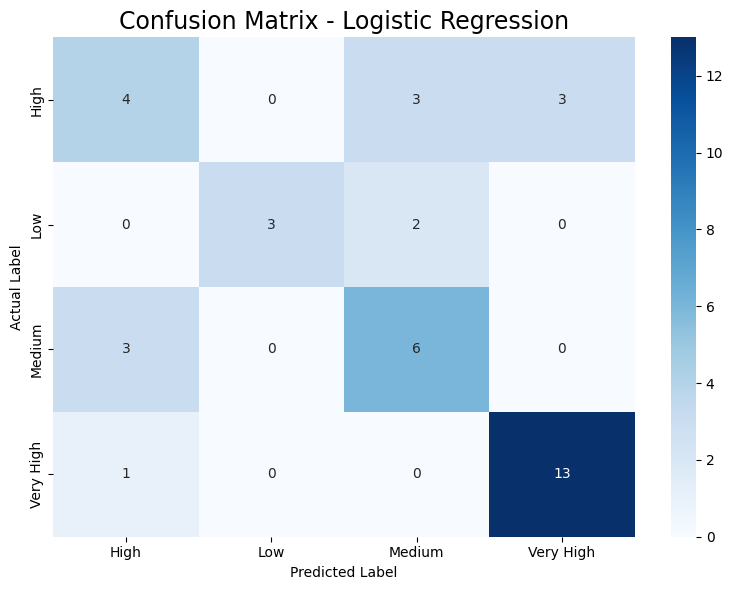

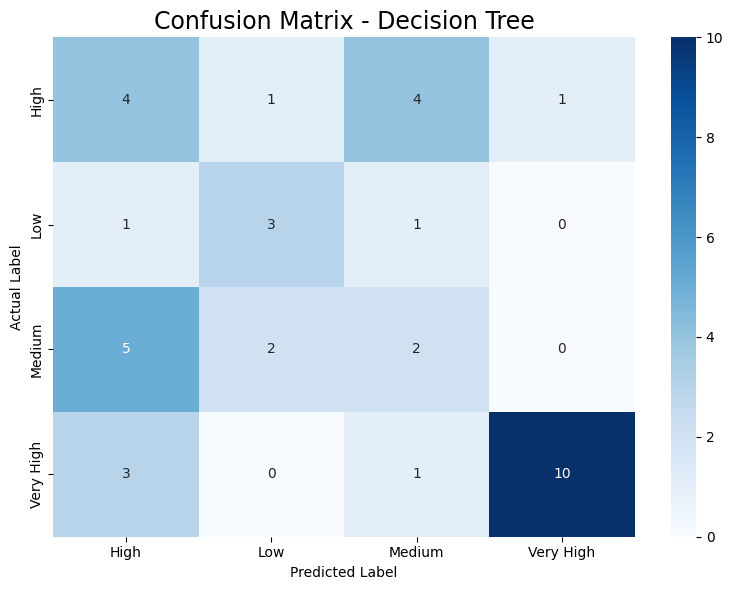

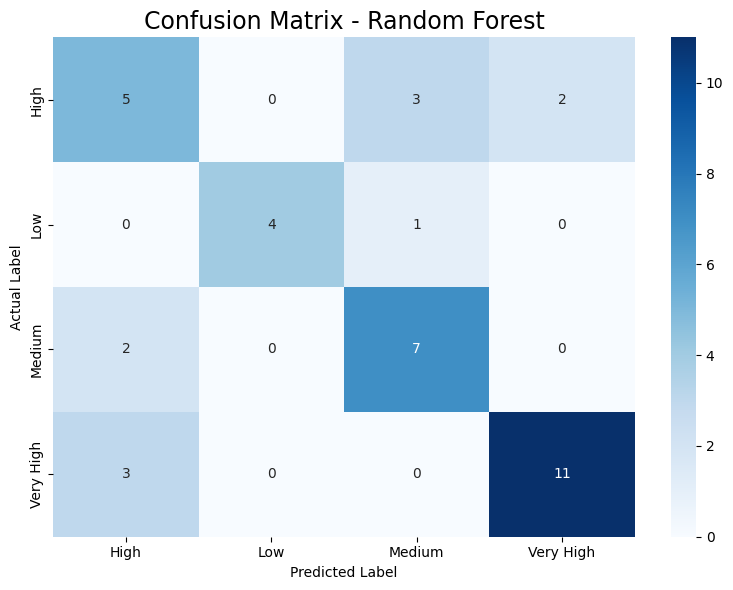

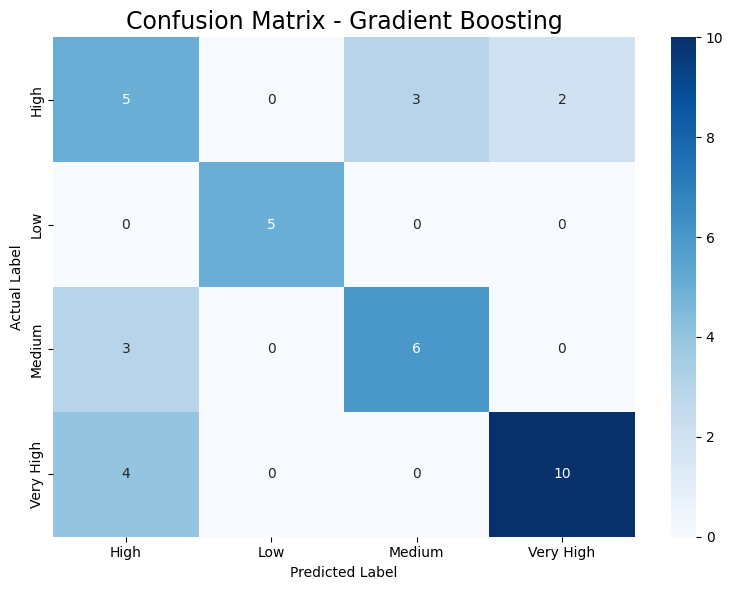

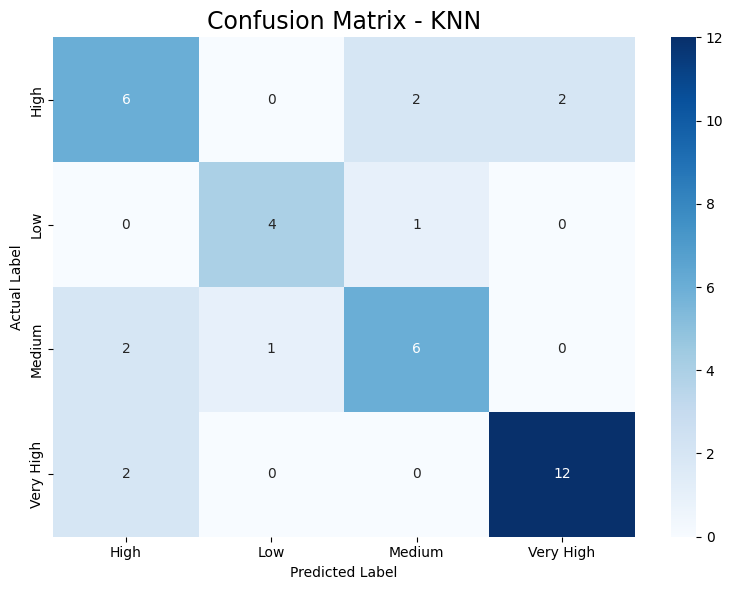

Logistic Regression Macro ROC-AUC: 0.8825
Decision Tree Macro ROC-AUC: 0.6698
Random Forest Macro ROC-AUC: 0.8967
Gradient Boosting Macro ROC-AUC: 0.8986
KNN Macro ROC-AUC: 0.8670


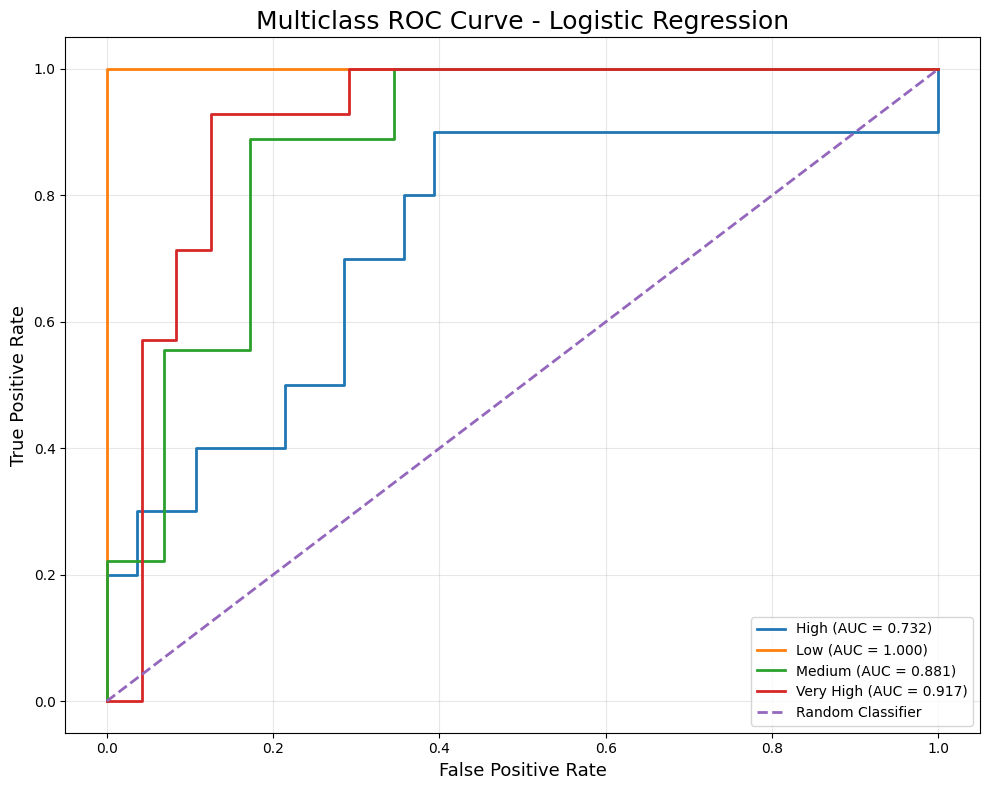

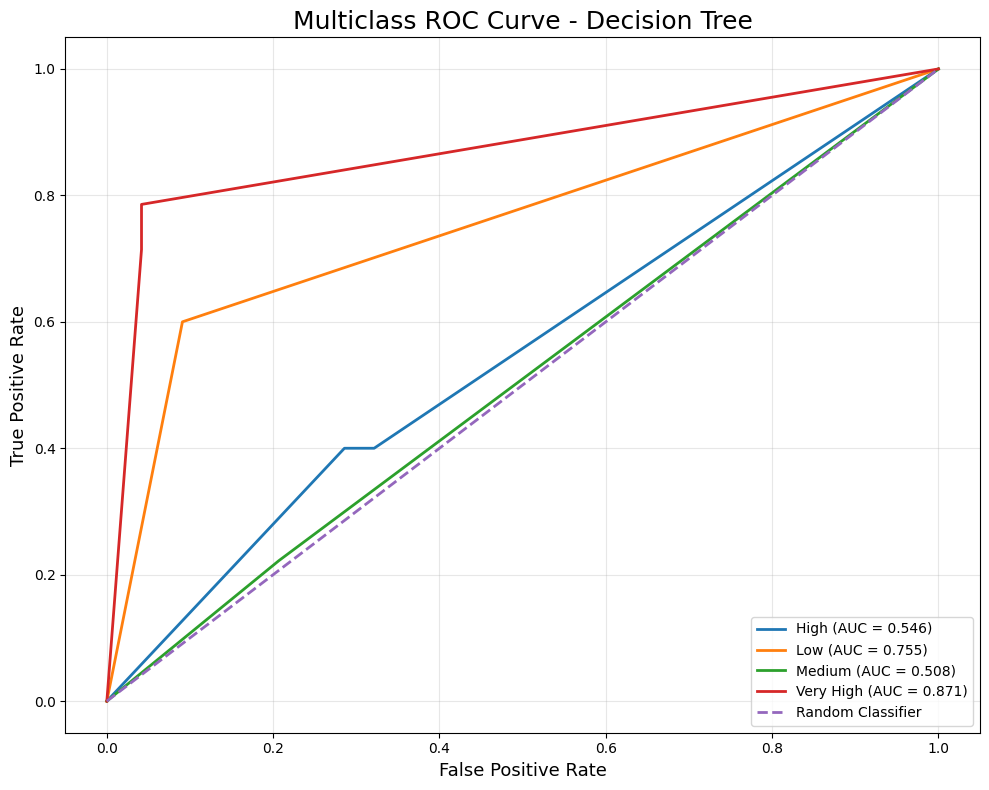

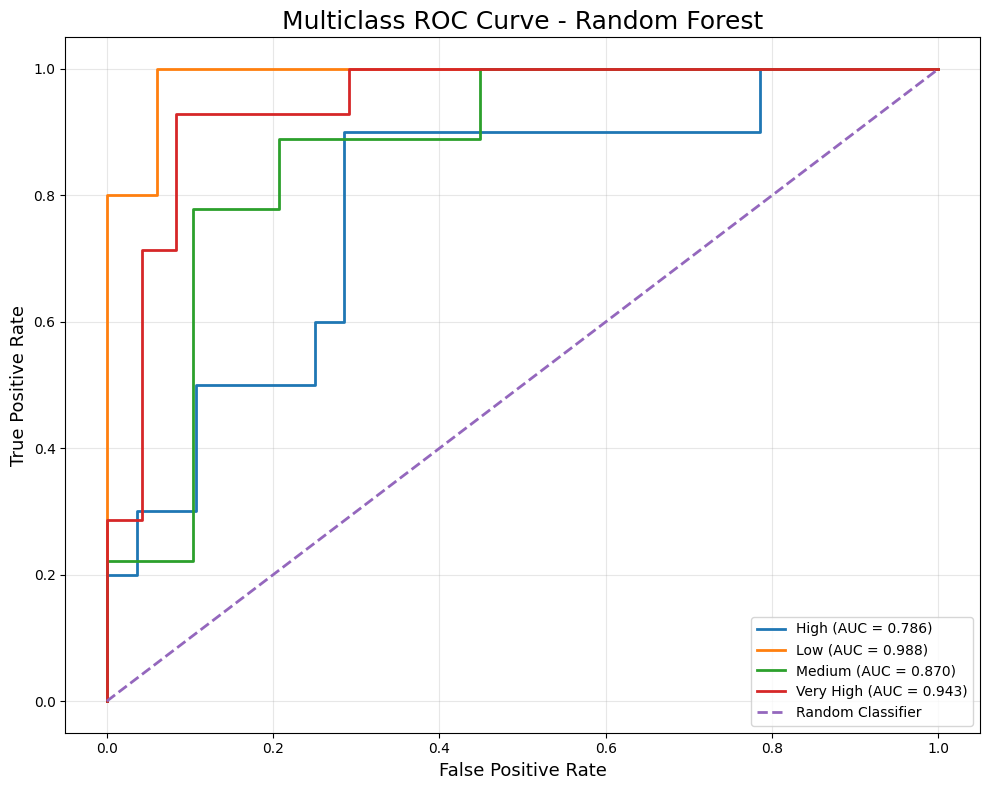

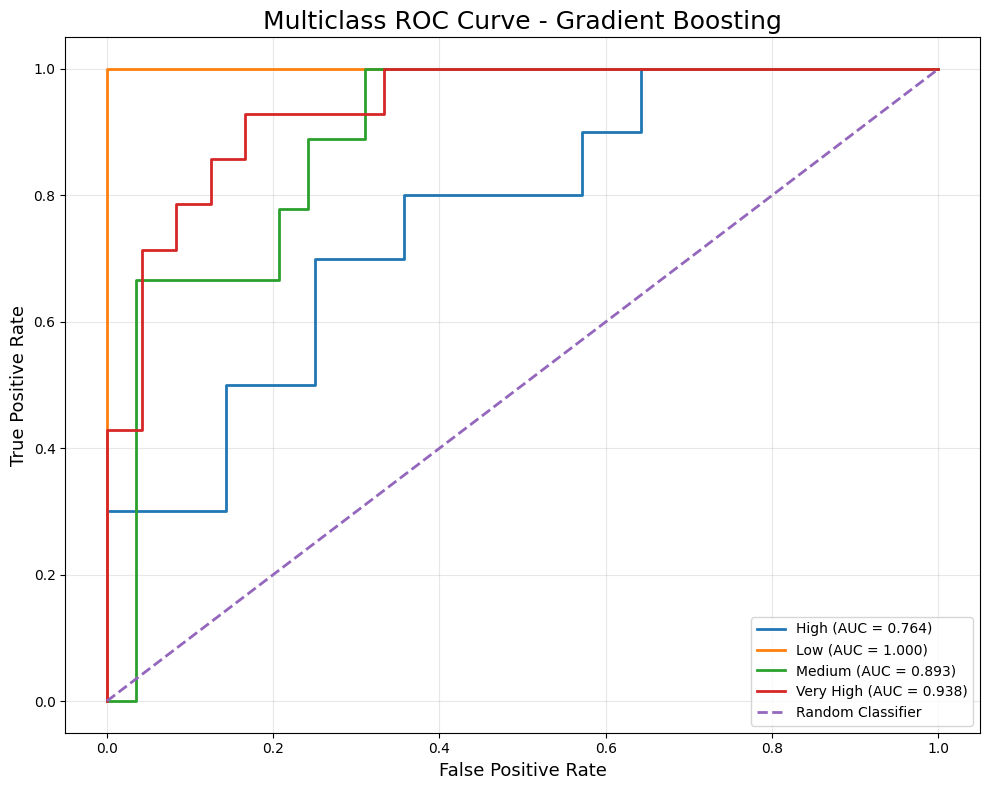

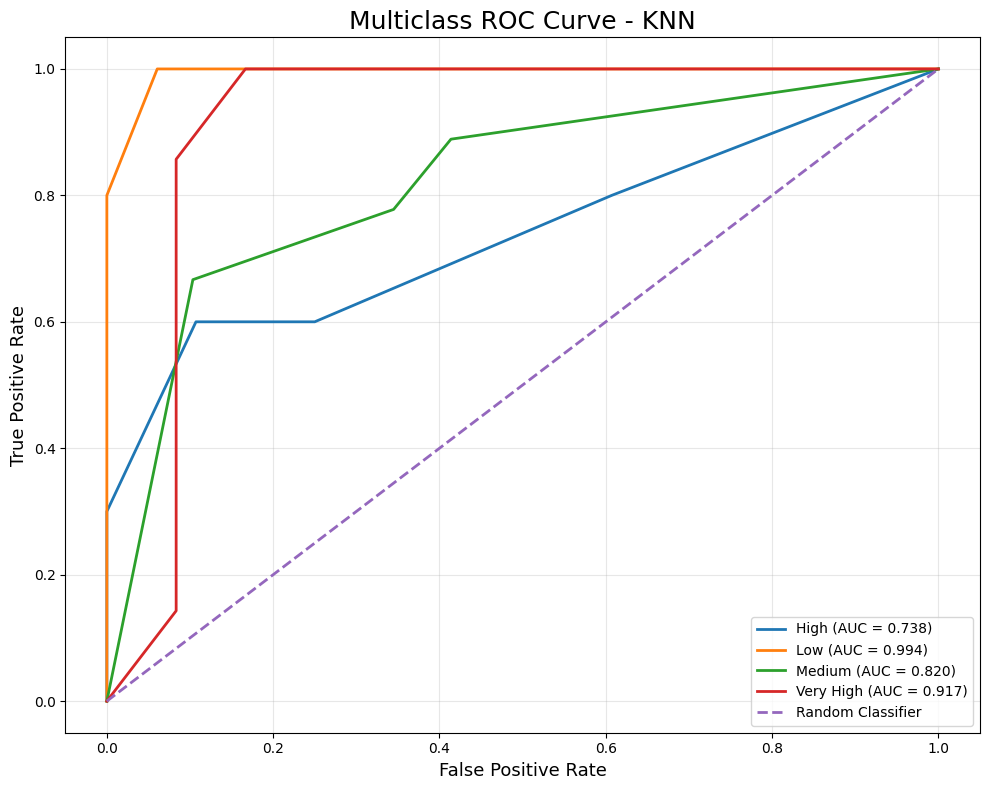



ROC-AUC MODEL COMPARISON


,Model,ROC_AUC
0,Gradient Boosting,0.8986
1,Random Forest,0.8967
2,Logistic Regression,0.8825
3,KNN,0.8670
4,Decision Tree,0.6698


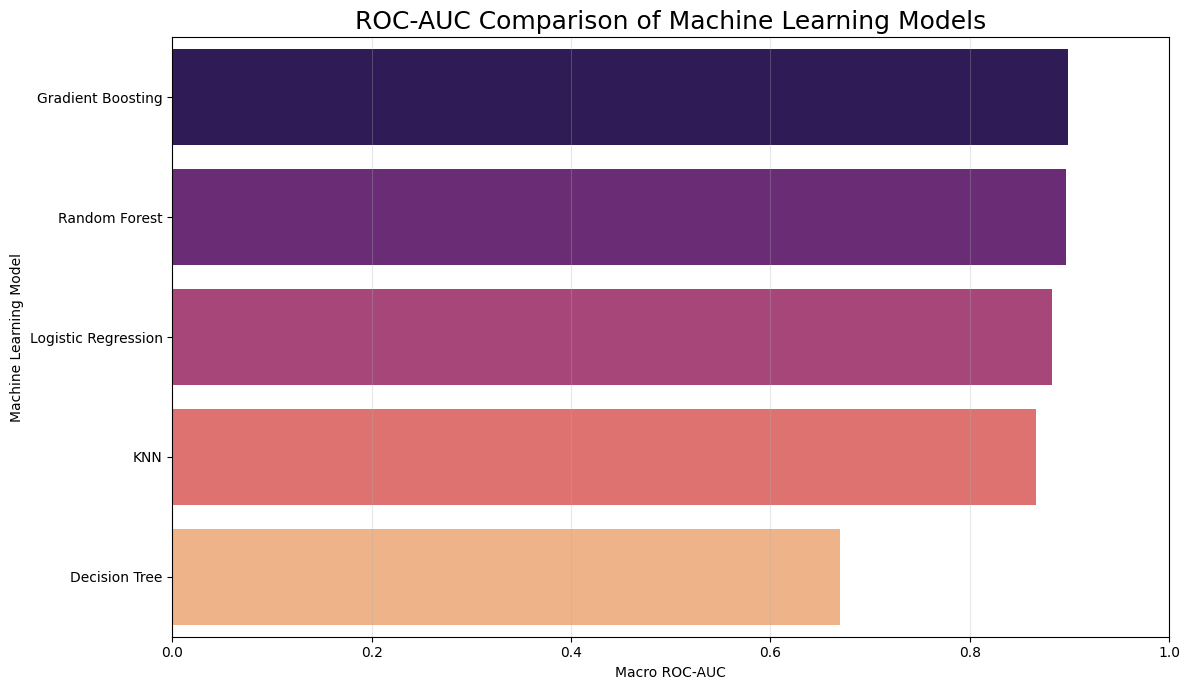



FINAL MACHINE LEARNING RESULTS


,Model,Accuracy,Precision,Recall,F1 Score,ROC_AUC
0,KNN,0.7368,0.7368,0.7368,0.7368,0.8670
1,Random Forest,0.7105,0.7256,0.7105,0.7145,0.8967
2,Logistic Regression,0.6842,0.6917,0.6842,0.6770,0.8825
3,Gradient Boosting,0.6842,0.7061,0.6842,0.6925,0.8986
4,Decision Tree,0.5000,0.5409,0.5000,0.5138,0.6698




MODEL WITH HIGHEST TEST ACCURACY
Model: KNN
Accuracy: 0.7368
Precision: 0.7368
Recall: 0.7368
F1 Score: 0.7368
ROC-AUC: 0.867


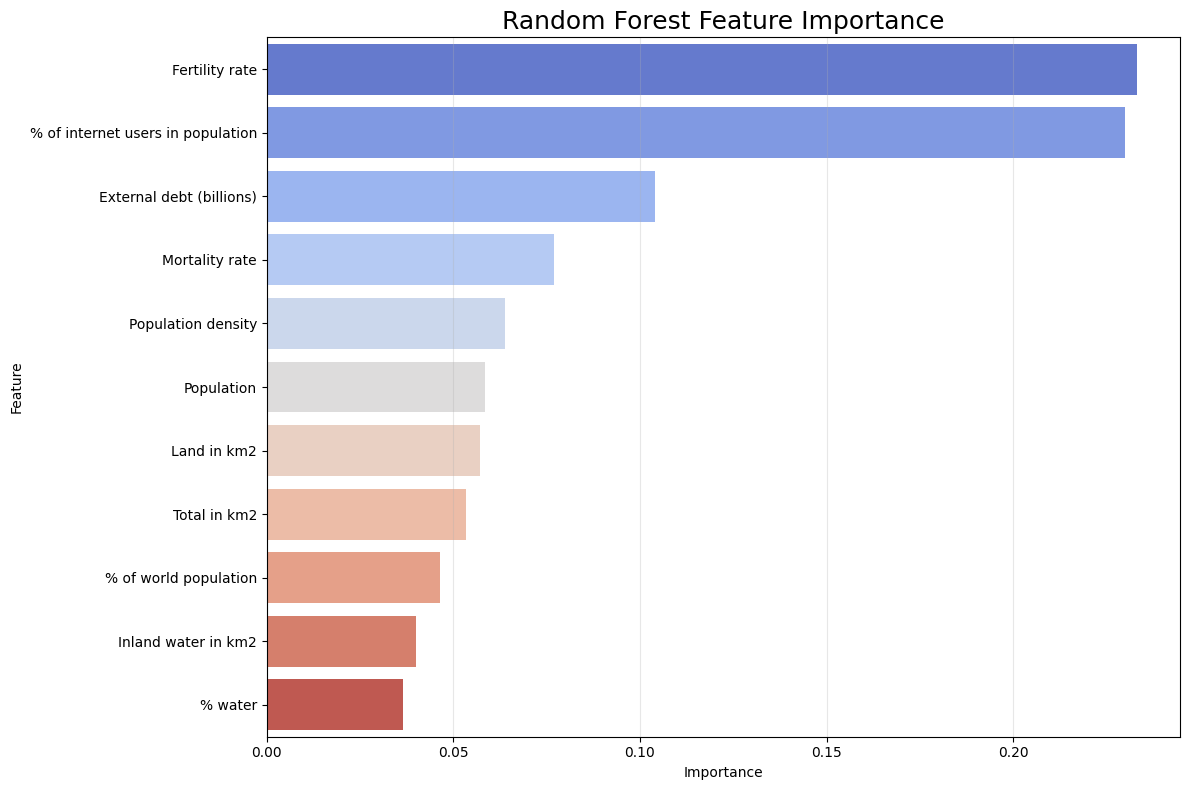



RANDOM FOREST FEATURE IMPORTANCE


,Feature,Importance
0,Fertility rate,0.233040
1,% of internet users in population,0.230032
2,External debt (billions),0.104082
3,Mortality rate,0.076891
4,Population density,0.063744
5,Population,0.058556
6,Land in km2,0.057266
7,Total in km2,0.053424
8,% of world population,0.046332
9,Inland water in km2,0.040121




SAMPLE PREDICTIONS


,Actual Encoded,Predicted Encoded,Actual Category,Predicted Category
0,3,0,Very High,High
1,3,3,Very High,Very High
2,3,3,Very High,Very High
3,3,3,Very High,Very High
4,1,1,Low,Low
5,1,1,Low,Low
6,2,2,Medium,Medium
7,0,2,High,Medium
8,2,2,Medium,Medium
9,0,0,High,High




MACHINE LEARNING PIPELINE COMPLETED
1. Dataset loaded
2. Numeric columns converted
3. HDI categories created
4. Target label encoded
5. Train/test split performed
6. Missing values handled
7. Feature scaling applied
8. Logistic Regression trained
9. Decision Tree trained
10. Random Forest trained
11. Gradient Boosting trained
12. KNN trained
13. Accuracy calculated
14. Precision calculated
15. Recall calculated
16. F1-score calculated
17. Confusion matrices generated
18. Multiclass ROC curves generated
19. ROC-AUC calculated
20. Feature importance calculated


In [14]:
# Train-test split
from sklearn.model_selection import train_test_split

# Label Encoding
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Missing values
from sklearn.impute import SimpleImputer

# Pipeline
from sklearn.pipeline import Pipeline

# Machine Learning Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score
)

# Multiclass ROC
from sklearn.preprocessing import label_binarize

import warnings
warnings.filterwarnings('ignore')


# ================================================================
# 2. COPY ORIGINAL DATASET
# ================================================================

df_ml = df.copy()

print("Dataset Shape:")
print(df_ml.shape)

print("\nColumns:")
print(df_ml.columns.tolist())

print("\nFirst 5 Rows:")
display(df_ml.head())


# ================================================================
# 3. CONVERT NUMERIC COLUMNS
# ================================================================

numeric_columns = [
    'Total in km2',
    'Land in km2',
    'Inland water in km2',
    '% water',
    'Population',
    '% of world population',
    'Population density',
    'HDI',
    'Fertility rate',
    'Mortality rate',
    '% of internet users in population',
    'External debt (billions)'
]

for col in numeric_columns:
    df_ml[col] = pd.to_numeric(
        df_ml[col],
        errors='coerce'
    )


# ================================================================
# 4. CHECK MISSING VALUES
# ================================================================

print("\nMissing Values:")
print(df_ml.isnull().sum())


# ================================================================
# 5. CREATE TARGET VARIABLE
# ================================================================
#
# The original dataset does not contain a classification target.
#
# We create HDI_Category using HDI:
#
# HDI < 0.55       -> Low
# 0.55 - 0.699     -> Medium
# 0.70 - 0.799     -> High
# >= 0.80          -> Very High
#
# IMPORTANT:
# HDI itself will NOT be used as a feature because it created
# the target. This prevents data leakage.
# ================================================================

def create_hdi_category(hdi):

    if pd.isna(hdi):
        return np.nan

    elif hdi < 0.55:
        return 'Low'

    elif hdi < 0.70:
        return 'Medium'

    elif hdi < 0.80:
        return 'High'

    else:
        return 'Very High'


df_ml['HDI_Category'] = df_ml['HDI'].apply(
    create_hdi_category
)


# ================================================================
# 6. CHECK TARGET DISTRIBUTION
# ================================================================

print("\nHDI Category Distribution:")
print(df_ml['HDI_Category'].value_counts())

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df_ml,
    x='HDI_Category',
    hue='HDI_Category',
    palette='Set2',
    legend=False
)

plt.title(
    'Distribution of HDI Categories',
    fontsize=18
)

plt.xlabel('HDI Category')
plt.ylabel('Number of Countries')

plt.grid(
    axis='y',
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ================================================================
# 7. REMOVE ROWS WITH MISSING TARGET
# ================================================================

df_ml = df_ml.dropna(
    subset=['HDI_Category']
).reset_index(drop=True)


# ================================================================
# 8. DEFINE FEATURES AND TARGET
# ================================================================

# Do NOT use:
#
# Country name -> identifier
# HDI          -> used to create target
# HDI_Category -> target itself

feature_columns = [
    'Total in km2',
    'Land in km2',
    'Inland water in km2',
    '% water',
    'Population',
    '% of world population',
    'Population density',
    'Fertility rate',
    'Mortality rate',
    '% of internet users in population',
    'External debt (billions)'
]

X = df_ml[feature_columns].copy()

y = df_ml['HDI_Category'].copy()


# ================================================================
# 9. DISPLAY FEATURES
# ================================================================

print("\nFeature Columns:")
print(X.columns.tolist())

print("\nTarget Column:")
print("HDI_Category")

print("\nX Shape:")
print(X.shape)

print("\ny Shape:")
print(y.shape)


# ================================================================
# 10. LABEL ENCODING
# ================================================================
#
# LabelEncoder converts:
#
# High       -> numerical label
# Low        -> numerical label
# Medium     -> numerical label
# Very High  -> numerical label
#
# We encode the target only.
# ================================================================

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("\nTarget Classes:")
print(label_encoder.classes_)

print("\nEncoded Target:")
print(np.unique(y_encoded))


# ================================================================
# 11. TRAIN TEST SPLIT
# ================================================================
#
# 80% Training
# 20% Testing
#
# stratify=y_encoded maintains the class distribution.
# ================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)


print("\nTraining Data Shape:")
print(X_train.shape)

print("\nTesting Data Shape:")
print(X_test.shape)

print("\nTraining Target Distribution:")
print(pd.Series(y_train).value_counts())

print("\nTesting Target Distribution:")
print(pd.Series(y_test).value_counts())


# ================================================================
# 12. PREPROCESSING PIPELINE
# ================================================================
#
# Median imputation:
# Missing numerical values are replaced with median.
#
# StandardScaler:
# Features are standardized.
#
# IMPORTANT:
# The preprocessing is fitted ONLY on training data through
# Pipeline. Therefore, there is no test-data leakage.
# ================================================================

preprocessor = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(strategy='median')
        ),
        (
            'scaler',
            StandardScaler()
        )
    ]
)


# ================================================================
# 13. DEFINE MACHINE LEARNING MODELS
# ================================================================

models = {

    'Logistic Regression':
        LogisticRegression(
            max_iter=2000,
            random_state=42
        ),

    'Decision Tree':
        DecisionTreeClassifier(
            max_depth=8,
            random_state=42
        ),

    'Random Forest':
        RandomForestClassifier(
            n_estimators=300,
            max_depth=10,
            random_state=42
        ),

    'Gradient Boosting':
        GradientBoostingClassifier(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ),

    'KNN':
        KNeighborsClassifier(
            n_neighbors=5
        )
}


# ================================================================
# 14. CREATE MODEL PIPELINES
# ================================================================

model_pipelines = {}

for model_name, model in models.items():

    model_pipelines[model_name] = Pipeline(
        steps=[
            (
                'preprocessing',
                preprocessor
            ),
            (
                'model',
                model
            )
        ]
    )


# ================================================================
# 15. TRAIN ALL MODELS
# ================================================================

trained_models = {}

for model_name, pipeline in model_pipelines.items():

    print("\n" + "=" * 70)
    print("TRAINING:", model_name)
    print("=" * 70)

    pipeline.fit(
        X_train,
        y_train
    )

    trained_models[model_name] = pipeline

    print("Training completed!")


# ================================================================
# 16. MODEL EVALUATION
# ================================================================

results = []

for model_name, model in trained_models.items():

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })


# ================================================================
# 17. MODEL COMPARISON TABLE
# ================================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    'Accuracy',
    ascending=False
).reset_index(drop=True)

print("\n")
print("=" * 80)
print("MODEL COMPARISON")
print("=" * 80)

display(
    results_df.style.format({
        'Accuracy': '{:.4f}',
        'Precision': '{:.4f}',
        'Recall': '{:.4f}',
        'F1 Score': '{:.4f}'
    })
)


# ================================================================
# 18. ACCURACY COMPARISON
# ================================================================

plt.figure(figsize=(12, 7))

sns.barplot(
    data=results_df,
    x='Accuracy',
    y='Model',
    hue='Model',
    palette='viridis',
    legend=False
)

plt.title(
    'Machine Learning Model Accuracy Comparison',
    fontsize=18
)

plt.xlabel('Accuracy')
plt.ylabel('Machine Learning Algorithm')

plt.xlim(0, 1)

plt.grid(
    axis='x',
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ================================================================
# 19. ALL METRICS COMPARISON
# ================================================================

metrics_melted = results_df.melt(
    id_vars='Model',
    value_vars=[
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ],
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(14, 8))

sns.barplot(
    data=metrics_melted,
    x='Model',
    y='Score',
    hue='Metric',
    palette='Set2'
)

plt.title(
    'Model Performance Comparison',
    fontsize=18
)

plt.xlabel('Machine Learning Model')
plt.ylabel('Score')

plt.ylim(0, 1.05)

plt.xticks(
    rotation=30,
    ha='right'
)

plt.grid(
    axis='y',
    alpha=0.3
)

plt.legend(
    title='Metric'
)

plt.tight_layout()
plt.show()


# ================================================================
# 20. CLASSIFICATION REPORT FOR EACH MODEL
# ================================================================

for model_name, model in trained_models.items():

    y_pred = model.predict(X_test)

    print("\n")
    print("=" * 80)
    print(model_name)
    print("=" * 80)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=label_encoder.classes_,
            zero_division=0
        )
    )


# ================================================================
# 21. CONFUSION MATRIX FOR EACH MODEL
# ================================================================

for model_name, model in trained_models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )

    plt.title(
        f'Confusion Matrix - {model_name}',
        fontsize=17
    )

    plt.xlabel('Predicted Label')
    plt.ylabel('Actual Label')

    plt.tight_layout()
    plt.show()


# ================================================================
# 22. ROC CURVE - MULTICLASS
# ================================================================
#
# Since HDI_Category has more than two classes, we use:
#
# One-vs-Rest (OvR)
#
# Each class gets its own ROC curve.
#
# Example:
#
# High vs Rest
# Low vs Rest
# Medium vs Rest
# Very High vs Rest
# ================================================================

# Convert test target to binary matrix

y_test_binarized = label_binarize(
    y_test,
    classes=np.arange(
        len(label_encoder.classes_)
    )
)


# ================================================================
# 23. ROC CURVE FOR EVERY MODEL
# ================================================================

roc_auc_results = {}

for model_name, model in trained_models.items():

    # Get probability predictions
    y_probability = model.predict_proba(X_test)

    # Calculate macro ROC-AUC
    macro_auc = roc_auc_score(
        y_test_binarized,
        y_probability,
        multi_class='ovr',
        average='macro'
    )

    roc_auc_results[model_name] = macro_auc

    print(
        f"{model_name} Macro ROC-AUC: "
        f"{macro_auc:.4f}"
    )


# ================================================================
# 24. DRAW MULTICLASS ROC CURVE FOR EACH MODEL
# ================================================================

for model_name, model in trained_models.items():

    y_probability = model.predict_proba(X_test)

    plt.figure(figsize=(10, 8))

    # ------------------------------------------
    # ROC curve for each class
    # ------------------------------------------

    for class_index, class_name in enumerate(
        label_encoder.classes_
    ):

        fpr, tpr, thresholds = roc_curve(
            y_test_binarized[:, class_index],
            y_probability[:, class_index]
        )

        roc_auc = auc(
            fpr,
            tpr
        )

        plt.plot(
            fpr,
            tpr,
            linewidth=2,
            label=f'{class_name} (AUC = {roc_auc:.3f})'
        )

    # ------------------------------------------
    # Random classifier line
    # ------------------------------------------

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle='--',
        linewidth=2,
        label='Random Classifier'
    )

    plt.title(
        f'Multiclass ROC Curve - {model_name}',
        fontsize=18
    )

    plt.xlabel(
        'False Positive Rate',
        fontsize=13
    )

    plt.ylabel(
        'True Positive Rate',
        fontsize=13
    )

    plt.legend(
        loc='lower right'
    )

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()


# ================================================================
# 25. ROC-AUC MODEL COMPARISON
# ================================================================

roc_results_df = pd.DataFrame(
    list(roc_auc_results.items()),
    columns=[
        'Model',
        'ROC_AUC'
    ]
)

roc_results_df = roc_results_df.sort_values(
    'ROC_AUC',
    ascending=False
).reset_index(drop=True)


print("\n")
print("=" * 70)
print("ROC-AUC MODEL COMPARISON")
print("=" * 70)

display(
    roc_results_df.style.format({
        'ROC_AUC': '{:.4f}'
    })
)


# ================================================================
# 26. ROC-AUC COMPARISON GRAPH
# ================================================================

plt.figure(figsize=(12, 7))

sns.barplot(
    data=roc_results_df,
    x='ROC_AUC',
    y='Model',
    hue='Model',
    palette='magma',
    legend=False
)

plt.title(
    'ROC-AUC Comparison of Machine Learning Models',
    fontsize=18
)

plt.xlabel('Macro ROC-AUC')
plt.ylabel('Machine Learning Model')

plt.xlim(0, 1)

plt.grid(
    axis='x',
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ================================================================
# 27. COMBINE ALL RESULTS
# ================================================================

final_results = results_df.merge(
    roc_results_df,
    on='Model'
)

final_results = final_results.sort_values(
    'Accuracy',
    ascending=False
).reset_index(drop=True)


print("\n")
print("=" * 90)
print("FINAL MACHINE LEARNING RESULTS")
print("=" * 90)

display(
    final_results.style.format({
        'Accuracy': '{:.4f}',
        'Precision': '{:.4f}',
        'Recall': '{:.4f}',
        'F1 Score': '{:.4f}',
        'ROC_AUC': '{:.4f}'
    })
)


# ================================================================
# 28. BEST MODEL INFORMATION
# ================================================================

best_model_name = final_results.iloc[0]['Model']

best_model = trained_models[
    best_model_name
]

print("\n")
print("=" * 70)
print("MODEL WITH HIGHEST TEST ACCURACY")
print("=" * 70)

print(
    "Model:",
    best_model_name
)

print(
    "Accuracy:",
    round(
        final_results.iloc[0]['Accuracy'],
        4
    )
)

print(
    "Precision:",
    round(
        final_results.iloc[0]['Precision'],
        4
    )
)

print(
    "Recall:",
    round(
        final_results.iloc[0]['Recall'],
        4
    )
)

print(
    "F1 Score:",
    round(
        final_results.iloc[0]['F1 Score'],
        4
    )
)

print(
    "ROC-AUC:",
    round(
        final_results.iloc[0]['ROC_AUC'],
        4
    )
)


# ================================================================
# 29. FEATURE IMPORTANCE - RANDOM FOREST
# ================================================================
#
# This section explains which country variables are important
# for predicting HDI category.
# ================================================================

rf_model = trained_models[
    'Random Forest'
]

# Extract preprocessing
rf_preprocessor = rf_model.named_steps[
    'preprocessing'
]

# Extract actual Random Forest model
rf_classifier = rf_model.named_steps[
    'model'
]

# Feature names remain the same after numerical preprocessing
feature_names = feature_columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_classifier.feature_importances_
})

importance_df = importance_df.sort_values(
    'Importance',
    ascending=False
)


# ================================================================
# 30. RANDOM FOREST FEATURE IMPORTANCE GRAPH
# ================================================================

plt.figure(figsize=(12, 8))

sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature',
    hue='Feature',
    palette='coolwarm',
    legend=False
)

plt.title(
    'Random Forest Feature Importance',
    fontsize=18
)

plt.xlabel('Importance')
plt.ylabel('Feature')

plt.grid(
    axis='x',
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ================================================================
# 31. PRINT FEATURE IMPORTANCE
# ================================================================

print("\n")
print("=" * 70)
print("RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 70)

display(
    importance_df.reset_index(drop=True)
)


# ================================================================
# 32. SAMPLE PREDICTIONS
# ================================================================

sample_predictions = best_model.predict(
    X_test.head(10)
)

sample_actual = y_test[:10]


prediction_comparison = pd.DataFrame({

    'Actual Encoded':
        sample_actual,

    'Predicted Encoded':
        sample_predictions,

    'Actual Category':
        label_encoder.inverse_transform(
            sample_actual
        ),

    'Predicted Category':
        label_encoder.inverse_transform(
            sample_predictions
        )
})


print("\n")
print("=" * 80)
print("SAMPLE PREDICTIONS")
print("=" * 80)

display(
    prediction_comparison
)


# ================================================================
# 33. FINAL SUMMARY
# ================================================================

print("\n")
print("=" * 80)
print("MACHINE LEARNING PIPELINE COMPLETED")
print("=" * 80)

print("1. Dataset loaded")
print("2. Numeric columns converted")
print("3. HDI categories created")
print("4. Target label encoded")
print("5. Train/test split performed")
print("6. Missing values handled")
print("7. Feature scaling applied")
print("8. Logistic Regression trained")
print("9. Decision Tree trained")
print("10. Random Forest trained")
print("11. Gradient Boosting trained")
print("12. KNN trained")
print("13. Accuracy calculated")
print("14. Precision calculated")
print("15. Recall calculated")
print("16. F1-score calculated")
print("17. Confusion matrices generated")
print("18. Multiclass ROC curves generated")
print("19. ROC-AUC calculated")
print("20. Feature importance calculated")
print("=" * 80)

## Thank you..pls upvote!!!!!!!!